# Notebook 03 -- Modeling

This notebook trains and evaluates predictive models for March Madness NCAA tournament
outcomes using **rolling window features** from all games (regular season + tournament).

**Key design decisions:**
- **Rolling window features** (last 5/7/10 games) capture team form and momentum
- **~80K men's + ~54K women's training rows** (vs. ~1,400 tournament-only before)
- **Time-based splits** (no random split) -- tournament prediction is temporal
- **Separate M/W models** with different regularization strategies
- **Feature selection** via mutual information + multicollinearity analysis

Workflow:
1. Load and prepare training data
2. Data overview and separation by gender
3. Time-based train/val/test split
4. Feature selection analysis
5. Baseline: Logistic Regression
6. Gradient Boosting Models (XGBoost + LightGBM)
7. Hyperparameter Tuning with Optuna
8. Final Model Training and Evaluation
9. Model Diagnostics
10. Save best models and feature lists

## 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Silence non-critical warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Plotting configuration
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
})
sns.set_style("whitegrid")

# Paths
OUTPUT_DIR = Path("..") / "outputs"
RANDOM_STATE = 42

print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: /Users/sidthakur/Github/mm-2026/outputs


In [2]:
# Load gender-specific rolling window training data produced by Notebook 02
try:
    m_df = pd.read_parquet(OUTPUT_DIR / "m_training_data.parquet", engine="pyarrow")
    w_df = pd.read_parquet(OUTPUT_DIR / "w_training_data.parquet", engine="pyarrow")
except Exception:
    print("Parquet read failed, falling back to CSV...")
    m_df = pd.read_csv(OUTPUT_DIR / "m_training_data.csv")
    w_df = pd.read_csv(OUTPUT_DIR / "w_training_data.csv")

print(f"Men's training data:   {m_df.shape}")
print(f"Women's training data: {w_df.shape}")
print(f"\nMen's columns:   {list(m_df.columns)}")
print(f"Women's columns: {list(w_df.columns)}")

Men's training data:   (79349, 54)
Women's training data: (54275, 53)

Men's columns:   ['Win_roll5', 'PointDiff_roll5', 'Score_roll5', 'OppScore_roll5', 'eFG_pct_roll5', 'ts_pct_roll5', 'to_rate_roll5', 'ast_to_ratio_roll5', 'off_reb_pct_roll5', 'def_reb_pct_roll5', 'game_off_eff_roll5', 'game_def_eff_roll5', 'scoring_consistency_roll5', 'eff_margin_roll5', 'Win_roll7', 'PointDiff_roll7', 'Score_roll7', 'OppScore_roll7', 'eFG_pct_roll7', 'ts_pct_roll7', 'to_rate_roll7', 'ast_to_ratio_roll7', 'off_reb_pct_roll7', 'def_reb_pct_roll7', 'game_off_eff_roll7', 'game_def_eff_roll7', 'scoring_consistency_roll7', 'eff_margin_roll7', 'Win_roll10', 'PointDiff_roll10', 'Score_roll10', 'OppScore_roll10', 'eFG_pct_roll10', 'ts_pct_roll10', 'to_rate_roll10', 'ast_to_ratio_roll10', 'off_reb_pct_roll10', 'def_reb_pct_roll10', 'game_off_eff_roll10', 'game_def_eff_roll10', 'scoring_consistency_roll10', 'eff_margin_roll10', 'target', 'Season', 'DayNum', 'TeamA', 'TeamB', 'is_tourney', 'static_sos', 'stat

## 2. Data Overview

In [3]:
# Overview of training data
for label, df in [("Men's", m_df), ("Women's", w_df)]:
    print(f"{label} data: {df.shape[0]:,} rows, seasons {int(df['Season'].min())}-{int(df['Season'].max())}")
    print(f"  Target: {df['target'].value_counts().to_dict()}")
    print(f"  NaN: {df.isnull().any(axis=1).sum()} rows")
    print(f"  Tournament rows: {df['is_tourney'].sum():,}")
    print(f"  Regular season rows: {(~df['is_tourney']).sum():,}")
    print()

Men's data: 79,349 rows, seasons 2003-2026
  Target: {0: 40533, 1: 38816}
  NaN: 0 rows
  Tournament rows: 1,449
  Regular season rows: 77,900

Women's data: 54,275 rows, seasons 2010-2026
  Target: {1: 27655, 0: 26620}
  NaN: 0 rows
  Tournament rows: 961
  Regular season rows: 53,314



In [4]:
# Season-by-season game counts
print("Men's games per season:")
print(m_df.groupby("Season").size().to_string())
print("\nWomen's games per season:")
print(w_df.groupby("Season").size().to_string())

Men's games per season:
Season
2003    2930
2004    2895
2005    2951
2006    3010
2007    3294
2008    3379
2009    3430
2010    3449
2011    3452
2012    3466
2013    3531
2014    3527
2015    3530
2016    3561
2017    3585
2018    3587
2019    3645
2020    3452
2021    1978
2022    3490
2023    3736
2024    3743
2025    3778
2026    1950

Women's games per season:
Season
2010    3254
2011    3290
2012    3255
2013    3397
2014    3429
2015    3413
2016    3405
2017    3396
2018    3394
2019    3418
2020    3293
2021    1721
2022    3188
2023    3486
2024    3544
2025    3561
2026    1831


## 3. Train/Val/Test Split (Time-Based)

Tournament prediction is a temporal forecasting problem. We **never** randomly
split -- future seasons must not leak into training.

With rolling window features across all games, we now have ~79K men's and ~54K women's rows.

- **Men**: Train 2003-2022 (~66K games), Val 2023-2024 (~9K games), Test 2025 (~4.5K games)
- **Women**: Train 2010-2022 (~42K games), Val 2023-2024 (~7K games), Test 2025 (~3.5K games)

In [5]:
def split_by_season(df, feature_cols, train_range, val_seasons, test_season):
    """Split data into train/val/test by season boundaries.

    Parameters
    ----------
    df : pd.DataFrame
        Full dataset with 'Season', 'target', and feature columns.
    feature_cols : list[str]
        Column names to use as features.
    train_range : tuple[int, int]
        (min_season, max_season) inclusive range for training.
    val_seasons : tuple[int, ...]
        Seasons used for validation.
    test_season : int
        Season used for final test evaluation.

    Returns
    -------
    dict with keys X_train, y_train, X_val, y_val, X_test, y_test
    """
    train_mask = (df["Season"] >= train_range[0]) & (df["Season"] <= train_range[1])
    val_mask = df["Season"].isin(val_seasons)
    test_mask = df["Season"] == test_season

    splits = {
        "X_train": df.loc[train_mask, feature_cols].copy(),
        "y_train": df.loc[train_mask, "target"].copy(),
        "X_val":   df.loc[val_mask, feature_cols].copy(),
        "y_val":   df.loc[val_mask, "target"].copy(),
        "X_test":  df.loc[test_mask, feature_cols].copy(),
        "y_test":  df.loc[test_mask, "target"].copy(),
    }

    print(f"  Train: {splits['X_train'].shape[0]:,} rows (seasons {train_range[0]}-{train_range[1]})")
    print(f"  Val:   {splits['X_val'].shape[0]:,} rows (seasons {val_seasons})")
    print(f"  Test:  {splits['X_test'].shape[0]:,} rows (season {test_season})")

    return splits

## 4. Handle NaN and Prepare Features

Rolling window features should be NaN-free (min_periods enforced in Notebook 02).
Static features use universally-available metrics (SOS, win_pct, efficiency_margin)
so they should also be complete. We verify and handle any remaining NaN with
training-set medians.

In [6]:
# Define feature columns -- everything except metadata
NON_FEATURE_COLS = ["target", "Season", "DayNum", "TeamA", "TeamB", "is_tourney", "gender"]

# Men's and women's should have the same rolling features, but different static features
M_ALL_FEATURE_COLS = [c for c in m_df.columns if c not in NON_FEATURE_COLS]
W_ALL_FEATURE_COLS = [c for c in w_df.columns if c not in NON_FEATURE_COLS]

# Use men's as the superset for MI analysis
ALL_FEATURE_COLS = M_ALL_FEATURE_COLS

print(f"Men's raw feature columns:   {len(M_ALL_FEATURE_COLS)}")
print(f"Women's raw feature columns: {len(W_ALL_FEATURE_COLS)}")
print(f"\nRolling features: {len([c for c in M_ALL_FEATURE_COLS if '_roll' in c])}")
print(f"Static features (M): {len([c for c in M_ALL_FEATURE_COLS if 'static_' in c])}")
print(f"Static features (W): {len([c for c in W_ALL_FEATURE_COLS if 'static_' in c])}")
print(f"\nFeatures in men's but not women's: {sorted(set(M_ALL_FEATURE_COLS) - set(W_ALL_FEATURE_COLS))}")
print(f"Features in women's but not men's: {sorted(set(W_ALL_FEATURE_COLS) - set(M_ALL_FEATURE_COLS))}")

Men's raw feature columns:   47
Women's raw feature columns: 46

Rolling features: 42
Static features (M): 5
Static features (W): 4

Features in men's but not women's: ['static_kenpom_rank']
Features in women's but not men's: []


In [7]:
# Split men's data (train on 2003-2022, validate on 2023-2024, test on 2025)
print("Men's splits:")
m_splits = split_by_season(
    m_df, M_ALL_FEATURE_COLS,
    train_range=(2003, 2022), val_seasons=(2023, 2024), test_season=2025
)

# Split women's data (train on 2010-2022, validate on 2023-2024, test on 2025)
print("\nWomen's splits:")
w_splits = split_by_season(
    w_df, W_ALL_FEATURE_COLS,
    train_range=(2010, 2022), val_seasons=(2023, 2024), test_season=2025
)

Men's splits:


  Train: 66,142 rows (seasons 2003-2022)
  Val:   7,479 rows (seasons (2023, 2024))
  Test:  3,778 rows (season 2025)

Women's splits:
  Train: 41,853 rows (seasons 2010-2022)
  Val:   7,030 rows (seasons (2023, 2024))
  Test:  3,561 rows (season 2025)


In [8]:
def fill_missing_with_median(splits, feature_cols):
    """Fill NaN values using training set median (avoids data leakage)."""
    train_medians = splits["X_train"][feature_cols].median()
    for key in ["X_train", "X_val", "X_test"]:
        nan_before = splits[key].isna().sum().sum()
        splits[key] = splits[key].fillna(train_medians)
        nan_after = splits[key].isna().sum().sum()
        print(f"  {key}: {nan_before:,} NaNs -> {nan_after:,} NaNs")
    return splits, train_medians


print("Men's NaN handling:")
m_splits, m_medians = fill_missing_with_median(m_splits, M_ALL_FEATURE_COLS)

print("\nWomen's NaN handling:")
w_splits, w_medians = fill_missing_with_median(w_splits, W_ALL_FEATURE_COLS)

Men's NaN handling:
  X_train: 0 NaNs -> 0 NaNs
  X_val: 0 NaNs -> 0 NaNs
  X_test: 0 NaNs -> 0 NaNs

Women's NaN handling:
  X_train: 0 NaNs -> 0 NaNs
  X_val: 0 NaNs -> 0 NaNs
  X_test: 0 NaNs -> 0 NaNs


In [9]:
# Verify no NaN remain
for label, splits in [("Men's", m_splits), ("Women's", w_splits)]:
    for key in ["X_train", "X_val", "X_test"]:
        remaining = splits[key].isna().sum().sum()
        assert remaining == 0, f"{label} {key} still has {remaining} NaN values"
print("All NaN values handled successfully.")

All NaN values handled successfully.


## 5. Feature Selection Analysis

We use mutual information to rank features by predictive power, then check for
multicollinearity to remove redundant features.

With rolling window features (3 windows x 14 metrics = 42 rolling + 3 static = 45 features),
there will be high correlation between the same metric at different window sizes.
We'll prune redundant features to avoid multicollinearity.

In [10]:
# Compute mutual information on men's training data
mi_scores = mutual_info_classif(
    m_splits["X_train"], m_splits["y_train"],
    discrete_features=False, random_state=RANDOM_STATE, n_neighbors=5
)
mi_df = pd.DataFrame({
    "feature": ALL_FEATURE_COLS,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

print("Top 20 features by Mutual Information (Men's training data):")
print(mi_df.head(20).to_string(index=False))

Top 20 features by Mutual Information (Men's training data):
                  feature  mi_score
           static_win_pct  0.160688
       static_kenpom_rank  0.160327
 static_efficiency_margin  0.144877
static_sos_adj_eff_margin  0.142086
         PointDiff_roll10  0.090516
        eff_margin_roll10  0.089778
          PointDiff_roll7  0.078862
         eff_margin_roll7  0.077542
               Win_roll10  0.072499
          PointDiff_roll5  0.068351
         eff_margin_roll5  0.065144
      game_off_eff_roll10  0.062687
                Win_roll7  0.062592
       game_off_eff_roll7  0.052503
                Win_roll5  0.047935
       game_off_eff_roll5  0.046589
      game_def_eff_roll10  0.042476
            ts_pct_roll10  0.037437
       game_def_eff_roll7  0.036970
             Score_roll10  0.036019


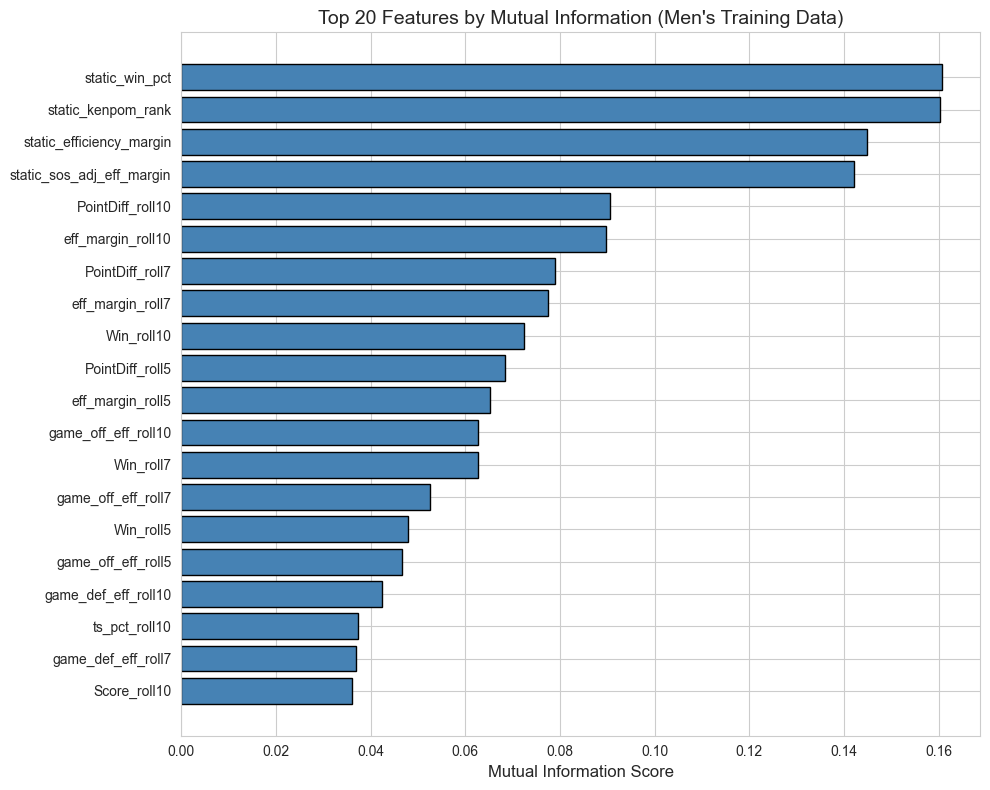

In [11]:
# Visualize top 20 MI scores
fig, ax = plt.subplots(figsize=(10, 8))
top20 = mi_df.head(20).sort_values("mi_score")
ax.barh(top20["feature"], top20["mi_score"], color="steelblue", edgecolor="black")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top 20 Features by Mutual Information (Men's Training Data)")
plt.tight_layout()
plt.show()

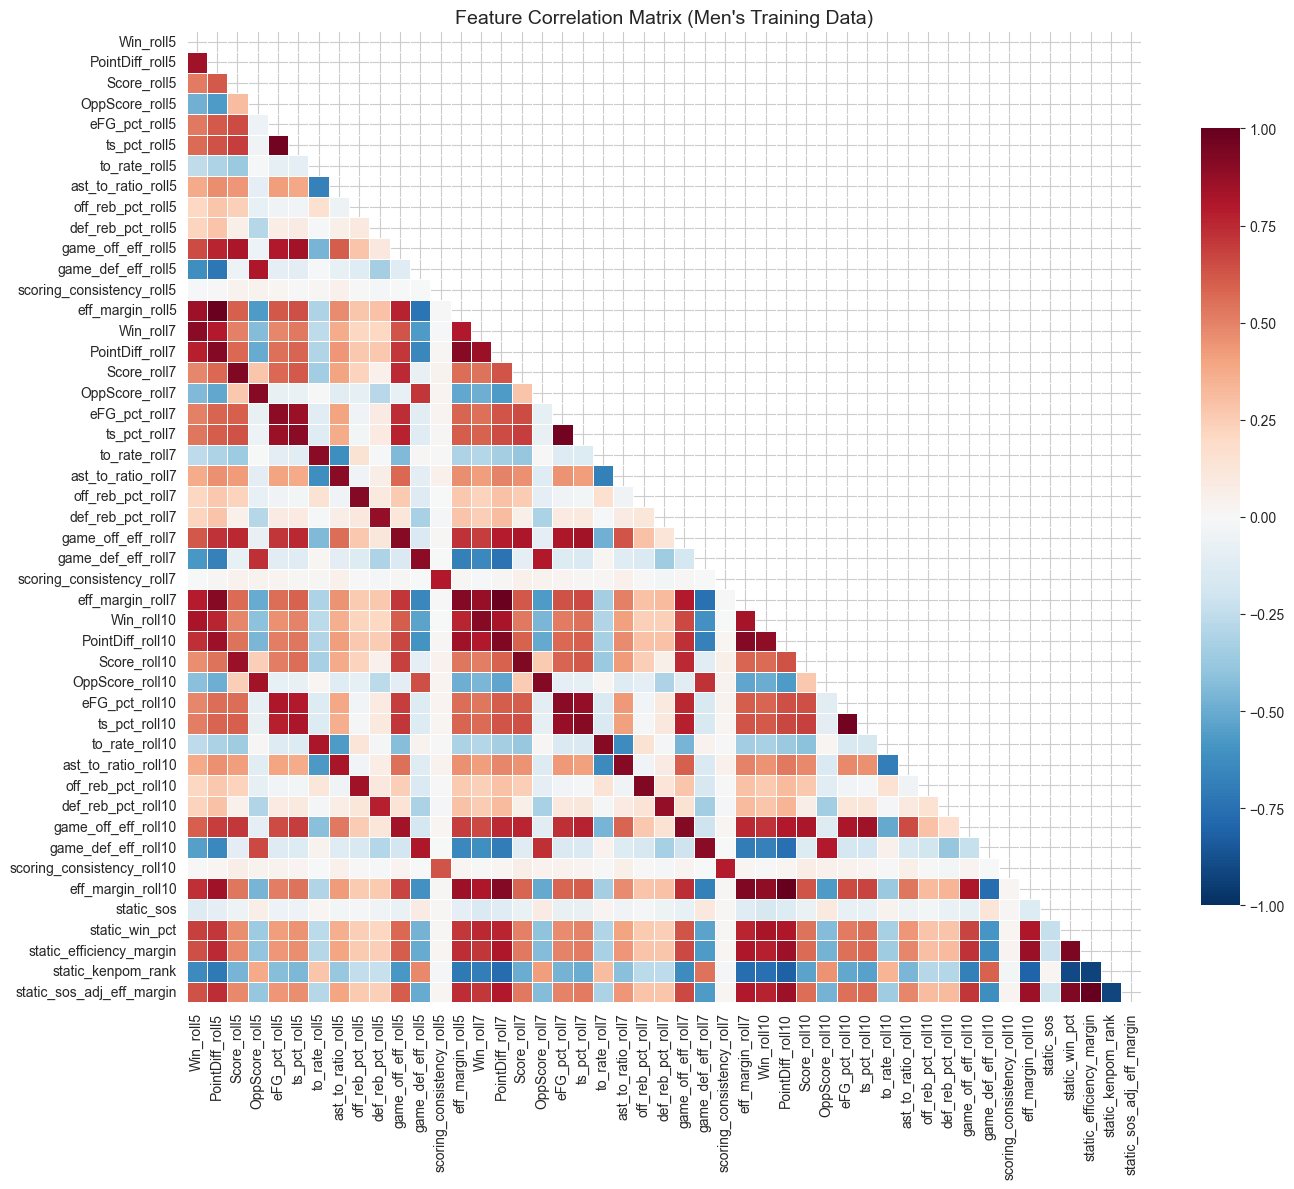

In [12]:
# Correlation matrix of all features to identify multicollinearity
corr_matrix = m_splits["X_train"][ALL_FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (Men's Training Data)")
plt.tight_layout()
plt.show()

In [13]:
# Identify highly correlated feature pairs (|r| > 0.85)
CORR_THRESHOLD = 0.85

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > CORR_THRESHOLD:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(r, 3),
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs, columns=["Feature A", "Feature B", "Correlation"]
).sort_values("Correlation", key=abs, ascending=False).reset_index(drop=True)

print(f"Feature pairs with |correlation| > {CORR_THRESHOLD}:")
print(high_corr_df.to_string(index=False))

Feature pairs with |correlation| > 0.85:
               Feature A                 Feature B  Correlation
static_efficiency_margin static_sos_adj_eff_margin        0.995
        PointDiff_roll10         eff_margin_roll10        0.992
         PointDiff_roll7          eff_margin_roll7        0.991
         PointDiff_roll5          eff_margin_roll5        0.990
          eFG_pct_roll10             ts_pct_roll10        0.965
           eFG_pct_roll7              ts_pct_roll7        0.963
           eFG_pct_roll5              ts_pct_roll5        0.961
          static_win_pct  static_efficiency_margin        0.941
          static_win_pct static_sos_adj_eff_margin        0.934
             Score_roll7              Score_roll10        0.933
         PointDiff_roll7          PointDiff_roll10        0.927
        eff_margin_roll7         eff_margin_roll10        0.927
       off_reb_pct_roll7        off_reb_pct_roll10        0.927
             Score_roll5               Score_roll7        0.925

In [14]:
# Drop highly correlated / redundant features for men's model
FEATURES_TO_DROP = set()

# Features to protect from correlation-based dropping.
# Both win_pct and kenpom_rank must survive: win_pct captures raw record,
# kenpom captures schedule-adjusted quality. Their correlation (-0.90) means
# ~19% unique variance -- exactly the SOS signal that fixes mid-major errors.
# win_pct is also critical for the women's model (which has no kenpom).
PROTECTED_FEATURES = {"static_kenpom_rank", "static_win_pct"}

# Build a lookup: feature -> MI score
mi_lookup = dict(zip(mi_df["feature"], mi_df["mi_score"]))

# For each highly correlated pair, drop the one with lower MI
for _, row in high_corr_df.iterrows():
    fa, fb = row["Feature A"], row["Feature B"]
    if fa in FEATURES_TO_DROP or fb in FEATURES_TO_DROP:
        continue
    # If both are protected, skip this pair entirely
    if fa in PROTECTED_FEATURES and fb in PROTECTED_FEATURES:
        continue
    # If one is protected, drop the other
    if fa in PROTECTED_FEATURES:
        FEATURES_TO_DROP.add(fb)
        continue
    if fb in PROTECTED_FEATURES:
        FEATURES_TO_DROP.add(fa)
        continue
    if mi_lookup.get(fa, 0) < mi_lookup.get(fb, 0):
        FEATURES_TO_DROP.add(fa)
    else:
        FEATURES_TO_DROP.add(fb)

print(f"Protected features: {sorted(PROTECTED_FEATURES)}")
print(f"Features to drop ({len(FEATURES_TO_DROP)}): {sorted(FEATURES_TO_DROP)}")

# Final feature list for men's model
M_FEATURE_COLS = [c for c in M_ALL_FEATURE_COLS if c not in FEATURES_TO_DROP]
print(f"\nMen's final features ({len(M_FEATURE_COLS)}): {M_FEATURE_COLS}")


Protected features: ['static_kenpom_rank', 'static_win_pct']
Features to drop (23): ['OppScore_roll10', 'OppScore_roll5', 'PointDiff_roll5', 'PointDiff_roll7', 'Score_roll5', 'Score_roll7', 'Win_roll10', 'Win_roll7', 'ast_to_ratio_roll7', 'def_reb_pct_roll7', 'eFG_pct_roll10', 'eFG_pct_roll5', 'eFG_pct_roll7', 'eff_margin_roll10', 'eff_margin_roll5', 'eff_margin_roll7', 'game_def_eff_roll7', 'game_off_eff_roll7', 'off_reb_pct_roll7', 'static_efficiency_margin', 'static_sos_adj_eff_margin', 'to_rate_roll7', 'ts_pct_roll7']

Men's final features (24): ['Win_roll5', 'ts_pct_roll5', 'to_rate_roll5', 'ast_to_ratio_roll5', 'off_reb_pct_roll5', 'def_reb_pct_roll5', 'game_off_eff_roll5', 'game_def_eff_roll5', 'scoring_consistency_roll5', 'OppScore_roll7', 'scoring_consistency_roll7', 'PointDiff_roll10', 'Score_roll10', 'ts_pct_roll10', 'to_rate_roll10', 'ast_to_ratio_roll10', 'off_reb_pct_roll10', 'def_reb_pct_roll10', 'game_off_eff_roll10', 'game_def_eff_roll10', 'scoring_consistency_roll10',

In [15]:
# For women's model: use fewer features to combat overfitting
# Women's dataset is smaller, so restrict to top features by MI.

# Get MI scores for features that exist in women's data
w_mi_candidates = mi_df[mi_df["feature"].isin(W_ALL_FEATURE_COLS)].copy()
w_mi_candidates = w_mi_candidates.sort_values("mi_score", ascending=False)

# Also exclude features we dropped for men (multicollinearity)
w_mi_candidates = w_mi_candidates[~w_mi_candidates["feature"].isin(FEATURES_TO_DROP)]

# Take top 20 for women (more data now, can afford a few more features)
W_FEATURE_COLS = w_mi_candidates["feature"].head(20).tolist()

print(f"Women's feature set ({len(W_FEATURE_COLS)} features):")
for i, col in enumerate(W_FEATURE_COLS, 1):
    mi_val = mi_lookup.get(col, 0)
    print(f"  {i:2d}. {col:30s} MI={mi_val:.4f}")

Women's feature set (20 features):
   1. static_win_pct                 MI=0.1607
   2. PointDiff_roll10               MI=0.0905
   3. game_off_eff_roll10            MI=0.0627
   4. Win_roll5                      MI=0.0479
   5. game_off_eff_roll5             MI=0.0466
   6. game_def_eff_roll10            MI=0.0425
   7. ts_pct_roll10                  MI=0.0374
   8. Score_roll10                   MI=0.0360
   9. ast_to_ratio_roll10            MI=0.0285
  10. game_def_eff_roll5             MI=0.0280
  11. ts_pct_roll5                   MI=0.0259
  12. OppScore_roll7                 MI=0.0232
  13. static_sos                     MI=0.0192
  14. ast_to_ratio_roll5             MI=0.0179
  15. to_rate_roll10                 MI=0.0179
  16. def_reb_pct_roll10             MI=0.0127
  17. off_reb_pct_roll10             MI=0.0118
  18. off_reb_pct_roll5              MI=0.0102
  19. def_reb_pct_roll5              MI=0.0088
  20. to_rate_roll5                  MI=0.0087


In [16]:
# Rebuild splits with selected features
for key in ["X_train", "X_val", "X_test"]:
    m_splits[key] = m_splits[key][M_FEATURE_COLS]
    w_splits[key] = w_splits[key][W_FEATURE_COLS]

print(f"Men's: {m_splits['X_train'].shape[1]} features, {m_splits['X_train'].shape[0]} train rows")
print(f"Women's: {w_splits['X_train'].shape[1]} features, {w_splits['X_train'].shape[0]} train rows")

Men's: 24 features, 66142 train rows
Women's: 20 features, 41853 train rows


## 6. Baseline: Logistic Regression

A simple linear baseline that any tree-based model must beat.

**Metrics:**
- **Log-loss** (competition metric) -- penalizes confident wrong predictions heavily
- **Brier score** -- mean squared error of probabilities, ranges 0 (perfect) to 1 (worst).
  A coin-flip baseline scores 0.25. Good calibrated models for college basketball
  typically score 0.20-0.22.
- **Accuracy** -- simple classification correctness at 0.5 threshold

In [17]:
def evaluate_model(model, X, y, dataset_label="Validation"):
    """Evaluate a classifier and return key metrics.

    Parameters
    ----------
    model : fitted classifier with predict_proba method.
    X : feature matrix.
    y : true labels.
    dataset_label : str for display.

    Returns
    -------
    dict with log_loss, brier_score, and accuracy.
    """
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    ll = log_loss(y, y_prob)
    bs = brier_score_loss(y, y_prob)
    acc = accuracy_score(y, y_pred)

    print(f"  {dataset_label}: log-loss={ll:.4f}, brier={bs:.4f}, accuracy={acc:.4f}")

    return {"log_loss": round(ll, 4), "brier_score": round(bs, 4), "accuracy": round(acc, 4)}

In [18]:
# Men's Logistic Regression
print("=" * 60)
print("MEN'S LOGISTIC REGRESSION")
print("=" * 60)

m_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
])
m_lr.fit(m_splits["X_train"], m_splits["y_train"])

m_lr_train = evaluate_model(m_lr, m_splits["X_train"], m_splits["y_train"], "Train")
m_lr_val = evaluate_model(m_lr, m_splits["X_val"], m_splits["y_val"], "Val")

MEN'S LOGISTIC REGRESSION
  Train: log-loss=0.5064, brier=0.1688, accuracy=0.7471
  Val: log-loss=0.5271, brier=0.1765, accuracy=0.7323


In [19]:
# Women's Logistic Regression
print("=" * 60)
print("WOMEN'S LOGISTIC REGRESSION")
print("=" * 60)

w_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, C=0.5, random_state=RANDOM_STATE)),
])
w_lr.fit(w_splits["X_train"], w_splits["y_train"])

w_lr_train = evaluate_model(w_lr, w_splits["X_train"], w_splits["y_train"], "Train")
w_lr_val = evaluate_model(w_lr, w_splits["X_val"], w_splits["y_val"], "Val")

# Check for overfitting gap
w_gap = w_lr_train["log_loss"] - w_lr_val["log_loss"]
print(f"\n  Train-Val log-loss gap: {w_gap:.4f} (negative = val worse, watch for large gaps)")

WOMEN'S LOGISTIC REGRESSION


  Train: log-loss=0.4462, brier=0.1458, accuracy=0.7868


  Val: log-loss=0.4532, brier=0.1483, accuracy=0.7825

  Train-Val log-loss gap: -0.0070 (negative = val worse, watch for large gaps)


## 7. Gradient Boosting Models

Train XGBoost and LightGBM with reasonable defaults, then pick the
better framework for Optuna hyperparameter tuning.

In [20]:
# Men's XGBoost (default params)
print("=" * 60)
print("MEN'S XGBOOST (default params)")
print("=" * 60)

m_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=3,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    verbosity=0,
)
m_xgb.fit(
    m_splits["X_train"], m_splits["y_train"],
    eval_set=[(m_splits["X_val"], m_splits["y_val"])],
    verbose=False,
)

m_xgb_train = evaluate_model(m_xgb, m_splits["X_train"], m_splits["y_train"], "Train")
m_xgb_val = evaluate_model(m_xgb, m_splits["X_val"], m_splits["y_val"], "Val")

MEN'S XGBOOST (default params)


  Train: log-loss=0.4743, brier=0.1570, accuracy=0.7651
  Val: log-loss=0.5302, brier=0.1775, accuracy=0.7310


In [21]:
# Men's LightGBM (default params)
print("=" * 60)
print("MEN'S LIGHTGBM (default params)")
print("=" * 60)

m_lgb = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=10,
    random_state=RANDOM_STATE,
    verbose=-1,
)
m_lgb.fit(
    m_splits["X_train"], m_splits["y_train"],
    eval_set=[(m_splits["X_val"], m_splits["y_val"])],
)

m_lgb_train = evaluate_model(m_lgb, m_splits["X_train"], m_splits["y_train"], "Train")
m_lgb_val = evaluate_model(m_lgb, m_splits["X_val"], m_splits["y_val"], "Val")

MEN'S LIGHTGBM (default params)


  Train: log-loss=0.4749, brier=0.1575, accuracy=0.7638
  Val: log-loss=0.5307, brier=0.1777, accuracy=0.7304


In [22]:
# Women's XGBoost (higher regularization for smaller dataset)
print("=" * 60)
print("WOMEN'S XGBOOST (regularized defaults)")
print("=" * 60)

w_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=5.0,
    min_child_weight=10,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    verbosity=0,
)
w_xgb.fit(
    w_splits["X_train"], w_splits["y_train"],
    eval_set=[(w_splits["X_val"], w_splits["y_val"])],
    verbose=False,
)

w_xgb_train = evaluate_model(w_xgb, w_splits["X_train"], w_splits["y_train"], "Train")
w_xgb_val = evaluate_model(w_xgb, w_splits["X_val"], w_splits["y_val"], "Val")
print(f"  Train-Val gap: {w_xgb_train['log_loss'] - w_xgb_val['log_loss']:.4f}")

WOMEN'S XGBOOST (regularized defaults)


  Train: log-loss=0.4434, brier=0.1445, accuracy=0.7890
  Val: log-loss=0.4567, brier=0.1492, accuracy=0.7809
  Train-Val gap: -0.0133


In [23]:
# Women's LightGBM (higher regularization for smaller dataset)
print("=" * 60)
print("WOMEN'S LIGHTGBM (regularized defaults)")
print("=" * 60)

w_lgb = LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=5.0,
    min_child_samples=20,
    random_state=RANDOM_STATE,
    verbose=-1,
)
w_lgb.fit(
    w_splits["X_train"], w_splits["y_train"],
    eval_set=[(w_splits["X_val"], w_splits["y_val"])],
)

w_lgb_train = evaluate_model(w_lgb, w_splits["X_train"], w_splits["y_train"], "Train")
w_lgb_val = evaluate_model(w_lgb, w_splits["X_val"], w_splits["y_val"], "Val")
print(f"  Train-Val gap: {w_lgb_train['log_loss'] - w_lgb_val['log_loss']:.4f}")

WOMEN'S LIGHTGBM (regularized defaults)


  Train: log-loss=0.4429, brier=0.1445, accuracy=0.7890
  Val: log-loss=0.4573, brier=0.1496, accuracy=0.7812
  Train-Val gap: -0.0144


In [24]:
# Determine which GBM framework performed better
print("GBM Framework Comparison (validation log-loss):")
print(f"  Men's  XGBoost:  {m_xgb_val['log_loss']:.4f}")
print(f"  Men's  LightGBM: {m_lgb_val['log_loss']:.4f}")
print(f"  Women's XGBoost:  {w_xgb_val['log_loss']:.4f}")
print(f"  Women's LightGBM: {w_lgb_val['log_loss']:.4f}")

m_best_gbm = "xgboost" if m_xgb_val["log_loss"] <= m_lgb_val["log_loss"] else "lightgbm"
w_best_gbm = "xgboost" if w_xgb_val["log_loss"] <= w_lgb_val["log_loss"] else "lightgbm"

print(f"\n  Best for Men's:   {m_best_gbm}")
print(f"  Best for Women's: {w_best_gbm}")

GBM Framework Comparison (validation log-loss):
  Men's  XGBoost:  0.5302
  Men's  LightGBM: 0.5307
  Women's XGBoost:  0.4567
  Women's LightGBM: 0.4573

  Best for Men's:   xgboost
  Best for Women's: xgboost


## 8. Hyperparameter Tuning with Optuna

We tune the best-performing GBM framework using the **same time-based
train/val split** (no cross-validation that would mix seasons).

For the women's model we apply **stronger regularization bounds** and
**fewer estimators** to prevent overfitting on the smaller dataset.

In [25]:
def make_optuna_objective(splits, framework, gender="M"):
    """Create an Optuna objective function for GBM tuning.

    Parameters
    ----------
    splits : dict with X_train, y_train, X_val, y_val.
    framework : str, 'xgboost' or 'lightgbm'.
    gender : str, 'M' or 'W' -- controls regularization bounds.

    Returns
    -------
    callable : Optuna objective function.
    """
    # Women's model uses tighter bounds for stronger regularization
    is_women = gender == "W"

    def objective(trial):
        lr = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
        n_est = trial.suggest_int("n_estimators", 50, 500 if is_women else 800)
        max_d = trial.suggest_int("max_depth", 2 if is_women else 3, 5 if is_women else 8)
        subsample = trial.suggest_float("subsample", 0.5, 0.9 if is_women else 1.0)
        colsample = trial.suggest_float("colsample_bytree", 0.5, 0.9 if is_women else 1.0)
        reg_alpha = trial.suggest_float("reg_alpha", 0.01, 10.0, log=True)
        reg_lambda = trial.suggest_float("reg_lambda", 0.1 if is_women else 0.01, 20.0 if is_women else 10.0, log=True)

        if framework == "xgboost":
            mcw = trial.suggest_int("min_child_weight", 5 if is_women else 1, 30 if is_women else 15)
            model = XGBClassifier(
                n_estimators=n_est, max_depth=max_d, learning_rate=lr,
                subsample=subsample, colsample_bytree=colsample,
                min_child_weight=mcw, reg_alpha=reg_alpha, reg_lambda=reg_lambda,
                random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0,
            )
            model.fit(
                splits["X_train"], splits["y_train"],
                eval_set=[(splits["X_val"], splits["y_val"])],
                verbose=False,
            )
        else:
            mcs = trial.suggest_int("min_child_samples", 10 if is_women else 5, 60 if is_women else 50)
            model = LGBMClassifier(
                n_estimators=n_est, max_depth=max_d, learning_rate=lr,
                subsample=subsample, colsample_bytree=colsample,
                min_child_samples=mcs, reg_alpha=reg_alpha, reg_lambda=reg_lambda,
                random_state=RANDOM_STATE, verbose=-1,
            )
            model.fit(
                splits["X_train"], splits["y_train"],
                eval_set=[(splits["X_val"], splits["y_val"])],
            )

        y_prob = model.predict_proba(splits["X_val"])[:, 1]
        val_ll = log_loss(splits["y_val"], y_prob)
        val_bs = brier_score_loss(splits["y_val"], y_prob)

        # Also track train metrics to monitor overfitting
        y_prob_train = model.predict_proba(splits["X_train"])[:, 1]
        train_ll = log_loss(splits["y_train"], y_prob_train)
        train_bs = brier_score_loss(splits["y_train"], y_prob_train)
        trial.set_user_attr("train_log_loss", round(train_ll, 4))
        trial.set_user_attr("train_val_gap", round(train_ll - val_ll, 4))
        trial.set_user_attr("val_brier", round(val_bs, 4))
        trial.set_user_attr("train_brier", round(train_bs, 4))

        return val_ll

    return objective

In [26]:
N_TRIALS = 50

# --- Men's Tuning ---
print("=" * 60)
print(f"MEN'S OPTUNA TUNING ({m_best_gbm}, {N_TRIALS} trials)")
print("=" * 60)

m_study = optuna.create_study(direction="minimize", study_name="mm_men_tuning")
m_objective = make_optuna_objective(m_splits, m_best_gbm, gender="M")
m_study.optimize(m_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest men's trial:")
print(f"  Val log-loss:   {m_study.best_value:.4f}")
print(f"  Val brier:      {m_study.best_trial.user_attrs['val_brier']}")
print(f"  Train log-loss: {m_study.best_trial.user_attrs['train_log_loss']}")
print(f"  Train brier:    {m_study.best_trial.user_attrs['train_brier']}")
print(f"  Train-Val gap:  {m_study.best_trial.user_attrs['train_val_gap']}")
print(f"  Parameters:")
for k, v in m_study.best_params.items():
    print(f"    {k}: {v}")

MEN'S OPTUNA TUNING (xgboost, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]


Best men's trial:
  Val log-loss:   0.5282
  Val brier:      0.177
  Train log-loss: 0.4995
  Train brier:    0.1664
  Train-Val gap:  -0.0287
  Parameters:
    learning_rate: 0.010069628676982124
    n_estimators: 774
    max_depth: 4
    subsample: 0.9248589001072999
    colsample_bytree: 0.8985359622213963
    reg_alpha: 0.8063134522524321
    reg_lambda: 0.9414034003970618
    min_child_weight: 13


In [27]:
# --- Women's Tuning ---
print("=" * 60)
print(f"WOMEN'S OPTUNA TUNING ({w_best_gbm}, {N_TRIALS} trials)")
print("=" * 60)

w_study = optuna.create_study(direction="minimize", study_name="mm_women_tuning")
w_objective = make_optuna_objective(w_splits, w_best_gbm, gender="W")
w_study.optimize(w_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest women's trial:")
print(f"  Val log-loss:   {w_study.best_value:.4f}")
print(f"  Val brier:      {w_study.best_trial.user_attrs['val_brier']}")
print(f"  Train log-loss: {w_study.best_trial.user_attrs['train_log_loss']}")
print(f"  Train brier:    {w_study.best_trial.user_attrs['train_brier']}")
print(f"  Train-Val gap:  {w_study.best_trial.user_attrs['train_val_gap']}")
print(f"  Parameters:")
for k, v in w_study.best_params.items():
    print(f"    {k}: {v}")

# Flag if overfitting detected
w_gap = w_study.best_trial.user_attrs["train_val_gap"]
if abs(w_gap) > 0.15:
    print(f"\n  WARNING: Train-Val gap of {w_gap:.4f} suggests possible overfitting.")
    print("  Consider using the logistic regression model for women instead.")

WOMEN'S OPTUNA TUNING (xgboost, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]


Best women's trial:
  Val log-loss:   0.4541
  Val brier:      0.1486
  Train log-loss: 0.4336
  Train brier:    0.1412
  Train-Val gap:  -0.0205
  Parameters:
    learning_rate: 0.13034768763328342
    n_estimators: 434
    max_depth: 2
    subsample: 0.6588105159980027
    colsample_bytree: 0.7488983292941428
    reg_alpha: 2.293869878641238
    reg_lambda: 0.2959463881123605
    min_child_weight: 16


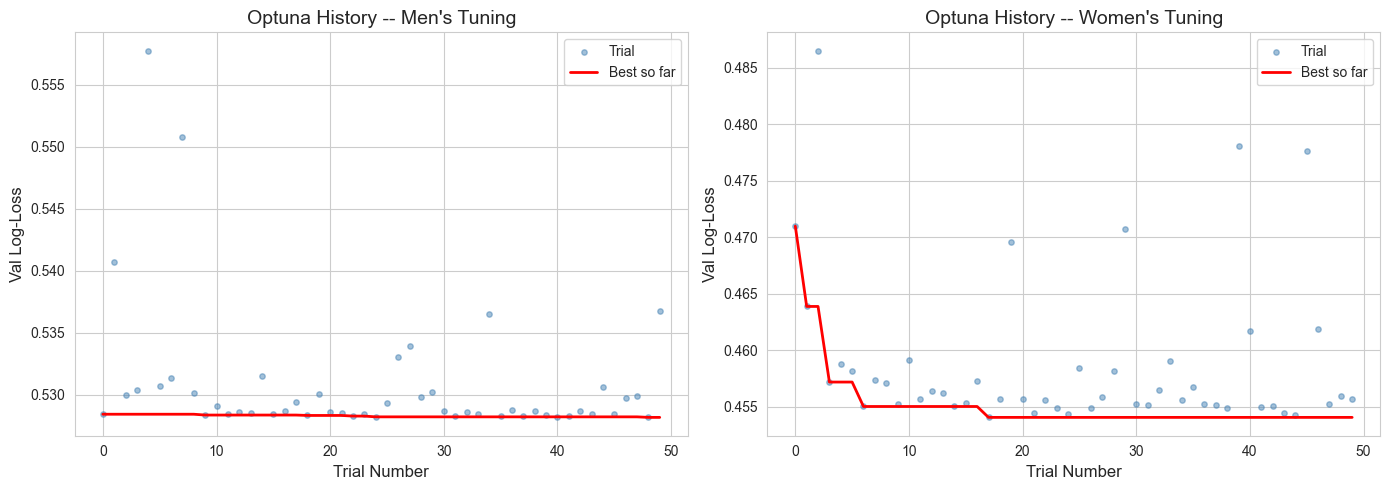

In [28]:
# Optuna optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, study, title in [
    (axes[0], m_study, "Men's Tuning"),
    (axes[1], w_study, "Women's Tuning"),
]:
    trial_numbers = [t.number for t in study.trials]
    trial_values = [t.value for t in study.trials]
    best_so_far = pd.Series(trial_values).cummin()

    ax.scatter(trial_numbers, trial_values, alpha=0.5, s=15, color="steelblue", label="Trial")
    ax.plot(trial_numbers, best_so_far, color="red", linewidth=2, label="Best so far")
    ax.set_title(f"Optuna History -- {title}")
    ax.set_xlabel("Trial Number")
    ax.set_ylabel("Val Log-Loss")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Final Model Training

Train final models with best hyperparameters on training data only (NOT
train+val -- we keep the temporal integrity). Evaluate on the held-out
2025 test set.

In [29]:
def build_final_model(best_params, framework, random_state=42):
    """Instantiate a model with the best Optuna parameters.

    Parameters
    ----------
    best_params : dict from study.best_params.
    framework : str, 'xgboost' or 'lightgbm'.
    random_state : int.

    Returns
    -------
    Unfitted model instance.
    """
    params = best_params.copy()
    if framework == "xgboost":
        params["random_state"] = random_state
        params["eval_metric"] = "logloss"
        params["verbosity"] = 0
        return XGBClassifier(**params)
    else:
        params["random_state"] = random_state
        params["verbose"] = -1
        return LGBMClassifier(**params)

In [30]:
# --- Men's Final Model ---
print("=" * 60)
print("MEN'S FINAL TUNED MODEL")
print("=" * 60)

m_final = build_final_model(m_study.best_params, m_best_gbm, RANDOM_STATE)

if m_best_gbm == "xgboost":
    m_final.fit(
        m_splits["X_train"], m_splits["y_train"],
        eval_set=[(m_splits["X_val"], m_splits["y_val"])],
        verbose=False,
    )
else:
    m_final.fit(
        m_splits["X_train"], m_splits["y_train"],
        eval_set=[(m_splits["X_val"], m_splits["y_val"])],
    )

m_final_train = evaluate_model(m_final, m_splits["X_train"], m_splits["y_train"], "Train")
m_final_val = evaluate_model(m_final, m_splits["X_val"], m_splits["y_val"], "Val")
m_final_test = evaluate_model(m_final, m_splits["X_test"], m_splits["y_test"], "Test (2025)")

MEN'S FINAL TUNED MODEL


  Train: log-loss=0.4995, brier=0.1664, accuracy=0.7501
  Val: log-loss=0.5282, brier=0.1770, accuracy=0.7341
  Test (2025): log-loss=0.5039, brier=0.1683, accuracy=0.7472


In [31]:
# --- Women's Final Model ---
print("=" * 60)
print("WOMEN'S FINAL TUNED MODEL")
print("=" * 60)

w_final = build_final_model(w_study.best_params, w_best_gbm, RANDOM_STATE)

if w_best_gbm == "xgboost":
    w_final.fit(
        w_splits["X_train"], w_splits["y_train"],
        eval_set=[(w_splits["X_val"], w_splits["y_val"])],
        verbose=False,
    )
else:
    w_final.fit(
        w_splits["X_train"], w_splits["y_train"],
        eval_set=[(w_splits["X_val"], w_splits["y_val"])],
    )

w_final_train = evaluate_model(w_final, w_splits["X_train"], w_splits["y_train"], "Train")
w_final_val = evaluate_model(w_final, w_splits["X_val"], w_splits["y_val"], "Val")
w_final_test = evaluate_model(w_final, w_splits["X_test"], w_splits["y_test"], "Test (2025)")

# Overfitting check
w_train_val_gap = w_final_train["log_loss"] - w_final_val["log_loss"]
w_val_acc = w_final_val["accuracy"]
print(f"\n  Train-Val log-loss gap: {w_train_val_gap:.4f}")
if w_val_acc > 0.95:
    print("  WARNING: Val accuracy > 95% -- possible overfitting or data leakage!")
if w_final_val["log_loss"] < 0.15:
    print("  WARNING: Val log-loss < 0.15 -- suspiciously low, check for leakage!")

WOMEN'S FINAL TUNED MODEL


  Train: log-loss=0.4336, brier=0.1412, accuracy=0.7942
  Val: log-loss=0.4541, brier=0.1486, accuracy=0.7832
  Test (2025): log-loss=0.4331, brier=0.1420, accuracy=0.7843

  Train-Val log-loss gap: -0.0205


In [32]:
# Model comparison table: all models x both genders x val and test metrics
comparison_rows = []

# Men's models
comparison_rows.append({
    "Gender": "Men", "Model": "Logistic Regression",
    "Val Log-Loss": m_lr_val["log_loss"], "Val Brier": m_lr_val["brier_score"],
    "Val Accuracy": m_lr_val["accuracy"],
    "Test Log-Loss": np.nan, "Test Brier": np.nan, "Test Accuracy": np.nan,
})
comparison_rows.append({
    "Gender": "Men", "Model": "XGBoost (default)",
    "Val Log-Loss": m_xgb_val["log_loss"], "Val Brier": m_xgb_val["brier_score"],
    "Val Accuracy": m_xgb_val["accuracy"],
    "Test Log-Loss": np.nan, "Test Brier": np.nan, "Test Accuracy": np.nan,
})
comparison_rows.append({
    "Gender": "Men", "Model": "LightGBM (default)",
    "Val Log-Loss": m_lgb_val["log_loss"], "Val Brier": m_lgb_val["brier_score"],
    "Val Accuracy": m_lgb_val["accuracy"],
    "Test Log-Loss": np.nan, "Test Brier": np.nan, "Test Accuracy": np.nan,
})
comparison_rows.append({
    "Gender": "Men", "Model": f"Tuned {m_best_gbm.title()} (FINAL)",
    "Val Log-Loss": m_final_val["log_loss"], "Val Brier": m_final_val["brier_score"],
    "Val Accuracy": m_final_val["accuracy"],
    "Test Log-Loss": m_final_test["log_loss"], "Test Brier": m_final_test["brier_score"],
    "Test Accuracy": m_final_test["accuracy"],
})

# Women's models
comparison_rows.append({
    "Gender": "Women", "Model": "Logistic Regression",
    "Val Log-Loss": w_lr_val["log_loss"], "Val Brier": w_lr_val["brier_score"],
    "Val Accuracy": w_lr_val["accuracy"],
    "Test Log-Loss": np.nan, "Test Brier": np.nan, "Test Accuracy": np.nan,
})
comparison_rows.append({
    "Gender": "Women", "Model": "XGBoost (regularized)",
    "Val Log-Loss": w_xgb_val["log_loss"], "Val Brier": w_xgb_val["brier_score"],
    "Val Accuracy": w_xgb_val["accuracy"],
    "Test Log-Loss": np.nan, "Test Brier": np.nan, "Test Accuracy": np.nan,
})
comparison_rows.append({
    "Gender": "Women", "Model": "LightGBM (regularized)",
    "Val Log-Loss": w_lgb_val["log_loss"], "Val Brier": w_lgb_val["brier_score"],
    "Val Accuracy": w_lgb_val["accuracy"],
    "Test Log-Loss": np.nan, "Test Brier": np.nan, "Test Accuracy": np.nan,
})
comparison_rows.append({
    "Gender": "Women", "Model": f"Tuned {w_best_gbm.title()} (FINAL)",
    "Val Log-Loss": w_final_val["log_loss"], "Val Brier": w_final_val["brier_score"],
    "Val Accuracy": w_final_val["accuracy"],
    "Test Log-Loss": w_final_test["log_loss"], "Test Brier": w_final_test["brier_score"],
    "Test Accuracy": w_final_test["accuracy"],
})

comparison_df = pd.DataFrame(comparison_rows)

# Reorder columns for readability
col_order = ["Gender", "Model", "Val Log-Loss", "Val Brier", "Val Accuracy",
             "Test Log-Loss", "Test Brier", "Test Accuracy"]
comparison_df = comparison_df[col_order]

print("Model Comparison Summary")
print("=" * 110)
print("(Brier score: 0.25 = coin flip, <0.20 = good calibration)")
print()
comparison_df

Model Comparison Summary
(Brier score: 0.25 = coin flip, <0.20 = good calibration)



,Gender,Model,Val Log-Loss,Val Brier,Val Accuracy,Test Log-Loss,Test Brier,Test Accuracy
0,Men,Logistic Regression,0.5271,0.1765,0.7323,NaN,NaN,NaN
1,Men,XGBoost (default),0.5302,0.1775,0.7310,NaN,NaN,NaN
2,Men,LightGBM (default),0.5307,0.1777,0.7304,NaN,NaN,NaN
3,Men,Tuned Xgboost (FINAL),0.5282,0.1770,0.7341,0.5039,0.1683,0.7472
4,Women,Logistic Regression,0.4532,0.1483,0.7825,NaN,NaN,NaN
5,Women,XGBoost (regularized),0.4567,0.1492,0.7809,NaN,NaN,NaN
6,Women,LightGBM (regularized),0.4573,0.1496,0.7812,NaN,NaN,NaN
7,Women,Tuned Xgboost (FINAL),0.4541,0.1486,0.7832,0.4331,0.1420,0.7843


## Ensemble Comparison: Tier 1 vs Tier 2

**Why ensemble?** LR and tuned XGBoost have nearly identical validation scores
(Men's: 0.5274 vs 0.5279 log-loss) but likely make **different types of errors**.
LR captures linear relationships; XGBoost captures nonlinear interactions.
Averaging smooths overconfident tree predictions and reduces variance.

**Anti-overfitting safeguards:**
- Weight optimization on validation set only; test set (2025) remains untouched
- Tier 1 has **1** free parameter (α); Tier 2 has **2** (α, β) — minimal degrees of freedom
- Averaging inherently regularizes individual model overconfidence
- No stacking meta-learner (avoids overfitting to small validation set)

**Tier 1:** `pred = α·LR + (1-α)·XGB` (2 models)
**Tier 2:** `pred = α·LR + β·XGB + (1-α-β)·LGB` (3 models)

In [33]:
# Collect base model predictions on validation and test sets
# Reuse already-trained models: m_lr, m_final (tuned XGB), m_lgb (default LGB)

base_preds = {}

for gender, lr, xgb, lgb, splits in [
    ("M", m_lr, m_final, m_lgb, m_splits),
    ("W", w_lr, w_final, w_lgb, w_splits),
]:
    base_preds[gender] = {}
    for split_name, X, y in [
        ("train", splits["X_train"], splits["y_train"]),
        ("val", splits["X_val"], splits["y_val"]),
        ("test", splits["X_test"], splits["y_test"]),
    ]:
        base_preds[gender][split_name] = {
            "y": y,
            "lr": lr.predict_proba(X)[:, 1],
            "xgb": xgb.predict_proba(X)[:, 1],
            "lgb": lgb.predict_proba(X)[:, 1],
        }

# Quick sanity check: individual val log-losses should match earlier results
for g in ["M", "W"]:
    y_val = base_preds[g]["val"]["y"]
    print(f"{g} val log-loss  LR={log_loss(y_val, base_preds[g]['val']['lr']):.4f}"
          f"  XGB={log_loss(y_val, base_preds[g]['val']['xgb']):.4f}"
          f"  LGB={log_loss(y_val, base_preds[g]['val']['lgb']):.4f}")

M val log-loss  LR=0.5271  XGB=0.5282  LGB=0.5307
W val log-loss  LR=0.4532  XGB=0.4541  LGB=0.4573


In [34]:
# --- Tier 1: Weighted blend of LR + XGB ---
# Search alpha from 0.0 to 1.0: blend = alpha * LR + (1 - alpha) * XGB

alphas = np.arange(0.0, 1.01, 0.01)
tier1_results = {}

for gender in ["M", "W"]:
    y_val = base_preds[gender]["val"]["y"]
    lr_val = base_preds[gender]["val"]["lr"]
    xgb_val = base_preds[gender]["val"]["xgb"]

    best_alpha, best_ll = 0.0, float("inf")
    ll_curve, bs_curve = [], []

    for alpha in alphas:
        blend = alpha * lr_val + (1 - alpha) * xgb_val
        ll = log_loss(y_val, blend)
        bs = brier_score_loss(y_val, blend)
        ll_curve.append(ll)
        bs_curve.append(bs)
        if ll < best_ll:
            best_ll = ll
            best_alpha = alpha

    # Evaluate best blend on test
    y_test = base_preds[gender]["test"]["y"]
    lr_test = base_preds[gender]["test"]["lr"]
    xgb_test = base_preds[gender]["test"]["xgb"]
    best_blend_val = best_alpha * lr_val + (1 - best_alpha) * xgb_val
    best_blend_test = best_alpha * lr_test + (1 - best_alpha) * xgb_test

    tier1_results[gender] = {
        "best_alpha": round(best_alpha, 2),
        "val_ll": round(log_loss(y_val, best_blend_val), 4),
        "val_bs": round(brier_score_loss(y_val, best_blend_val), 4),
        "val_acc": round(accuracy_score(y_val, (best_blend_val >= 0.5).astype(int)), 4),
        "test_ll": round(log_loss(y_test, best_blend_test), 4),
        "test_bs": round(brier_score_loss(y_test, best_blend_test), 4),
        "test_acc": round(accuracy_score(y_test, (best_blend_test >= 0.5).astype(int)), 4),
        "ll_curve": ll_curve,
        "bs_curve": bs_curve,
    }

    print(f"\n{gender} Tier 1 (LR + XGB):")
    print(f"  Best alpha = {best_alpha:.2f} (LR weight)")
    print(f"  Val:  log-loss={tier1_results[gender]['val_ll']:.4f}, "
          f"brier={tier1_results[gender]['val_bs']:.4f}, "
          f"acc={tier1_results[gender]['val_acc']:.4f}")
    print(f"  Test: log-loss={tier1_results[gender]['test_ll']:.4f}, "
          f"brier={tier1_results[gender]['test_bs']:.4f}, "
          f"acc={tier1_results[gender]['test_acc']:.4f}")


M Tier 1 (LR + XGB):
  Best alpha = 0.65 (LR weight)
  Val:  log-loss=0.5266, brier=0.1764, acc=0.7326
  Test: log-loss=0.5034, brier=0.1682, acc=0.7472



W Tier 1 (LR + XGB):
  Best alpha = 0.58 (LR weight)
  Val:  log-loss=0.4524, brier=0.1480, acc=0.7826
  Test: log-loss=0.4294, brier=0.1408, acc=0.7846


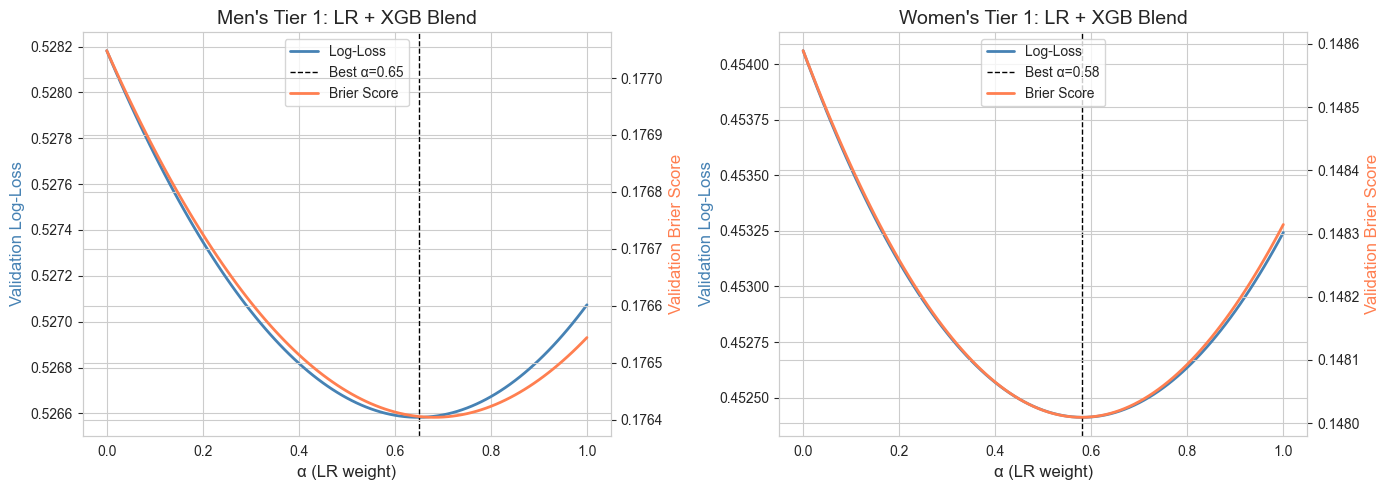

In [35]:
# Plot Tier 1: alpha vs validation metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gender, title in [
    (axes[0], "M", "Men's"),
    (axes[1], "W", "Women's"),
]:
    r = tier1_results[gender]
    ax2 = ax.twinx()

    ax.plot(alphas, r["ll_curve"], color="steelblue", linewidth=2, label="Log-Loss")
    ax2.plot(alphas, r["bs_curve"], color="coral", linewidth=2, label="Brier Score")

    ax.axvline(r["best_alpha"], color="black", linestyle="--", linewidth=1,
               label=f"Best α={r['best_alpha']:.2f}")
    ax.set_xlabel("α (LR weight)")
    ax.set_ylabel("Validation Log-Loss", color="steelblue")
    ax2.set_ylabel("Validation Brier Score", color="coral")
    ax.set_title(f"{title} Tier 1: LR + XGB Blend")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper center")

plt.tight_layout()
plt.show()

In [36]:
# --- Tier 2: Weighted blend of LR + XGB + LGB ---
# Search (alpha, beta) where gamma = 1 - alpha - beta, step 0.05

tier2_results = {}

for gender in ["M", "W"]:
    y_val = base_preds[gender]["val"]["y"]
    lr_val = base_preds[gender]["val"]["lr"]
    xgb_val = base_preds[gender]["val"]["xgb"]
    lgb_val = base_preds[gender]["val"]["lgb"]

    best_weights = (0.33, 0.34, 0.33)
    best_ll = float("inf")

    # Grid search with step 0.05
    step = 0.05
    for a in np.arange(0.0, 1.0 + step, step):
        for b in np.arange(0.0, 1.0 - a + step, step):
            g = 1.0 - a - b
            if g < -0.001:  # allow small float error
                continue
            g = max(g, 0.0)
            blend = a * lr_val + b * xgb_val + g * lgb_val
            ll = log_loss(y_val, blend)
            if ll < best_ll:
                best_ll = ll
                best_weights = (round(a, 2), round(b, 2), round(g, 2))

    # Evaluate best blend on test
    a, b, g = best_weights
    y_test = base_preds[gender]["test"]["y"]
    lr_test = base_preds[gender]["test"]["lr"]
    xgb_test = base_preds[gender]["test"]["xgb"]
    lgb_test = base_preds[gender]["test"]["lgb"]

    best_blend_val = a * lr_val + b * xgb_val + g * lgb_val
    best_blend_test = a * lr_test + b * xgb_test + g * lgb_test

    tier2_results[gender] = {
        "weights": best_weights,
        "labels": ["LR", "XGB", "LGB"],
        "val_ll": round(log_loss(y_val, best_blend_val), 4),
        "val_bs": round(brier_score_loss(y_val, best_blend_val), 4),
        "val_acc": round(accuracy_score(y_val, (best_blend_val >= 0.5).astype(int)), 4),
        "test_ll": round(log_loss(y_test, best_blend_test), 4),
        "test_bs": round(brier_score_loss(y_test, best_blend_test), 4),
        "test_acc": round(accuracy_score(y_test, (best_blend_test >= 0.5).astype(int)), 4),
    }

    print(f"\n{gender} Tier 2 (LR + XGB + LGB):")
    print(f"  Best weights: LR={a:.2f}, XGB={b:.2f}, LGB={g:.2f}")
    print(f"  Val:  log-loss={tier2_results[gender]['val_ll']:.4f}, "
          f"brier={tier2_results[gender]['val_bs']:.4f}, "
          f"acc={tier2_results[gender]['val_acc']:.4f}")
    print(f"  Test: log-loss={tier2_results[gender]['test_ll']:.4f}, "
          f"brier={tier2_results[gender]['test_bs']:.4f}, "
          f"acc={tier2_results[gender]['test_acc']:.4f}")


M Tier 2 (LR + XGB + LGB):
  Best weights: LR=0.65, XGB=0.35, LGB=0.00
  Val:  log-loss=0.5266, brier=0.1764, acc=0.7326
  Test: log-loss=0.5034, brier=0.1682, acc=0.7472



W Tier 2 (LR + XGB + LGB):
  Best weights: LR=0.60, XGB=0.40, LGB=0.00
  Val:  log-loss=0.4524, brier=0.1480, acc=0.7824
  Test: log-loss=0.4293, brier=0.1408, acc=0.7846


In [37]:
# --- Ensemble Comparison Table + Overfitting Analysis ---
ensemble_rows = []

for gender, label in [("M", "Men"), ("W", "Women")]:
    y_val = base_preds[gender]["val"]["y"]
    y_test = base_preds[gender]["test"]["y"]

    # Solo models
    for model_name, key in [("Solo LR", "lr"), ("Solo XGB (tuned)", "xgb"), ("Solo LGB (default)", "lgb")]:
        v_prob = base_preds[gender]["val"][key]
        t_prob = base_preds[gender]["test"][key]
        ensemble_rows.append({
            "Gender": label, "Approach": model_name,
            "Val LL": round(log_loss(y_val, v_prob), 4),
            "Val Brier": round(brier_score_loss(y_val, v_prob), 4),
            "Val Acc": round(accuracy_score(y_val, (v_prob >= 0.5).astype(int)), 4),
            "Test LL": round(log_loss(y_test, t_prob), 4),
            "Test Brier": round(brier_score_loss(y_test, t_prob), 4),
            "Test Acc": round(accuracy_score(y_test, (t_prob >= 0.5).astype(int)), 4),
        })

    # Tier 1
    t1 = tier1_results[gender]
    ensemble_rows.append({
        "Gender": label, "Approach": f"Tier 1 (α={t1['best_alpha']:.2f})",
        "Val LL": t1["val_ll"], "Val Brier": t1["val_bs"], "Val Acc": t1["val_acc"],
        "Test LL": t1["test_ll"], "Test Brier": t1["test_bs"], "Test Acc": t1["test_acc"],
    })

    # Tier 2
    t2 = tier2_results[gender]
    w = t2["weights"]
    ensemble_rows.append({
        "Gender": label,
        "Approach": f"Tier 2 ({w[0]:.2f}/{w[1]:.2f}/{w[2]:.2f})",
        "Val LL": t2["val_ll"], "Val Brier": t2["val_bs"], "Val Acc": t2["val_acc"],
        "Test LL": t2["test_ll"], "Test Brier": t2["test_bs"], "Test Acc": t2["test_acc"],
    })

ensemble_df = pd.DataFrame(ensemble_rows)

print("=" * 110)
print("ENSEMBLE COMPARISON: Tier 1 vs Tier 2")
print("=" * 110)
print("(Brier: 0.25 = coin flip, <0.20 = good calibration)")
print()
display(ensemble_df)

# Overfitting analysis: val-test gap
print("\n\nOVERFITTING ANALYSIS (Val LL - Test LL):")
print("  Negative gap = test performs better than val (no overfit)")
print("  Large positive gap = potential overfit to val set\n")
for _, row in ensemble_df.iterrows():
    gap = row["Val LL"] - row["Test LL"]
    flag = " ⚠️" if gap > 0.05 else ""
    print(f"  {row['Gender']:5s} {row['Approach']:35s}  gap = {gap:+.4f}{flag}")

ENSEMBLE COMPARISON: Tier 1 vs Tier 2
(Brier: 0.25 = coin flip, <0.20 = good calibration)



,Gender,Approach,Val LL,Val Brier,Val Acc,Test LL,Test Brier,Test Acc
0,Men,Solo LR,0.5271,0.1765,0.7323,0.5045,0.1686,0.7470
1,Men,Solo XGB (tuned),0.5282,0.1770,0.7341,0.5039,0.1683,0.7472
2,Men,Solo LGB (default),0.5307,0.1777,0.7304,0.5046,0.1686,0.7454
3,Men,Tier 1 (α=0.65),0.5266,0.1764,0.7326,0.5034,0.1682,0.7472
4,Men,Tier 2 (0.65/0.35/0.00),0.5266,0.1764,0.7326,0.5034,0.1682,0.7472
5,Women,Solo LR,0.4532,0.1483,0.7825,0.4286,0.1406,0.7818
6,Women,Solo XGB (tuned),0.4541,0.1486,0.7832,0.4331,0.1420,0.7843
7,Women,Solo LGB (default),0.4573,0.1496,0.7812,0.4336,0.1419,0.7871
8,Women,Tier 1 (α=0.58),0.4524,0.1480,0.7826,0.4294,0.1408,0.7846
9,Women,Tier 2 (0.60/0.40/0.00),0.4524,0.1480,0.7824,0.4293,0.1408,0.7846




OVERFITTING ANALYSIS (Val LL - Test LL):
  Negative gap = test performs better than val (no overfit)
  Large positive gap = potential overfit to val set

  Men   Solo LR                              gap = +0.0226
  Men   Solo XGB (tuned)                     gap = +0.0243
  Men   Solo LGB (default)                   gap = +0.0261
  Men   Tier 1 (α=0.65)                      gap = +0.0232
  Men   Tier 2 (0.65/0.35/0.00)              gap = +0.0232
  Women Solo LR                              gap = +0.0246
  Women Solo XGB (tuned)                     gap = +0.0210
  Women Solo LGB (default)                   gap = +0.0237
  Women Tier 1 (α=0.58)                      gap = +0.0230
  Women Tier 2 (0.60/0.40/0.00)              gap = +0.0231


In [38]:
# --- Pick Best Ensemble and Build Final EnsemblePredictor ---
import sys, os
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.model import EnsemblePredictor

# Decision: pick the tier with better val log-loss for each gender
# If Tier 2 is only marginally better (<0.001) but has more parameters, prefer Tier 1 for simplicity
MARGIN = 0.001

ensemble_config = {}

for gender, lr, xgb, lgb, splits in [
    ("M", m_lr, m_final, m_lgb, m_splits),
    ("W", w_lr, w_final, w_lgb, w_splits),
]:
    t1 = tier1_results[gender]
    t2 = tier2_results[gender]

    t2_improvement = t1["val_ll"] - t2["val_ll"]
    if t2_improvement > MARGIN:
        chosen = "tier2"
        w = t2["weights"]
        models = [lr, xgb, lgb]
        weights = list(w)
        model_names = ["LR", "XGB", "LGB"]
        chosen_val = t2
    else:
        chosen = "tier1"
        alpha = t1["best_alpha"]
        models = [lr, xgb]
        weights = [alpha, 1 - alpha]
        model_names = ["LR", "XGB"]
        chosen_val = t1

    ensemble = EnsemblePredictor(models, weights)
    ensemble_config[gender] = {
        "ensemble": ensemble,
        "tier": chosen,
        "weights": weights,
        "model_names": model_names,
        "val_ll": chosen_val["val_ll"],
        "test_ll": chosen_val["test_ll"],
    }

    # Verify ensemble produces correct predictions
    val_pred = ensemble.predict_proba(splits["X_val"])[:, 1]
    test_pred = ensemble.predict_proba(splits["X_test"])[:, 1]
    y_val = splits["y_val"]
    y_test = splits["y_test"]

    print(f"\n{gender} FINAL ENSEMBLE: {chosen.upper()}")
    print(f"  Models: {model_names}")
    print(f"  Weights: {[round(w, 3) for w in weights]}")
    print(f"  Val:  log-loss={log_loss(y_val, val_pred):.4f}, "
          f"brier={brier_score_loss(y_val, val_pred):.4f}, "
          f"acc={accuracy_score(y_val, (val_pred >= 0.5).astype(int)):.4f}")
    print(f"  Test: log-loss={log_loss(y_test, test_pred):.4f}, "
          f"brier={brier_score_loss(y_test, test_pred):.4f}, "
          f"acc={accuracy_score(y_test, (test_pred >= 0.5).astype(int)):.4f}")
    print(f"  Repr: {ensemble}")


M FINAL ENSEMBLE: TIER1
  Models: ['LR', 'XGB']
  Weights: [np.float64(0.65), np.float64(0.35)]
  Val:  log-loss=0.5266, brier=0.1764, acc=0.7326
  Test: log-loss=0.5034, brier=0.1682, acc=0.7472
  Repr: EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.650, 0.350], calibrator=None)

W FINAL ENSEMBLE: TIER1
  Models: ['LR', 'XGB']
  Weights: [np.float64(0.58), np.float64(0.42)]
  Val:  log-loss=0.4524, brier=0.1480, acc=0.7826
  Test: log-loss=0.4294, brier=0.1408, acc=0.7846
  Repr: EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.580, 0.420], calibrator=None)


## Probability Calibration

The Kaggle competition uses **log-loss** (and we also track **Brier score**). Both metrics
directly penalize miscalibrated probabilities -- outputting 0.9 when the true rate is 0.6
costs far more than outputting 0.65.

**Brier Score = Reliability - Resolution + Uncertainty**
- *Reliability* (calibration error): how close predicted probs are to observed frequencies
- *Resolution*: how well predictions separate wins from losses
- *Uncertainty*: inherent randomness (fixed for a given dataset)

We can't improve Resolution without a better model, but we **can** fix Reliability via calibration.

**Approach** (from temporal CV, tournament-only):
1. For each year Y from 2015-2025, train ensemble on all data before Y, predict Y's tournament
2. Pool ~700+ out-of-sample tournament predictions
3. Evaluate raw calibration (reliability diagram)
4. Compare **Platt scaling** (sigmoid, 2 params) vs **Isotonic regression** (nonparametric)
5. Fit calibrator on tournament-only OOS predictions, wrap final ensemble

**Key decisions:**
- Calibrate the **ensemble output**, not individual models
- Use **tournament games only** (different distribution than regular season)
- Start from **2015** (earlier years have weaker models with different error patterns)
- Platt scaling is preferred if miscalibration is sigmoid-shaped (more stable with ~700 samples)

In [39]:
%%time
# --- Temporal CV: Generate OOS Tournament Predictions ---
# For each year Y from 2015-2025:
#   - Train LR + XGB on all games from seasons < Y
#   - Predict tournament games in season Y (is_tourney == True)
#   - Blend with the same weights as our ensemble
#   - Collect (y_true, y_pred, season)

from sklearn.isotonic import IsotonicRegression

CV_START_YEAR = 2015
CV_END_YEAR = 2025

# Configs per gender: (df, feature_cols, lr_C, xgb_params, gbm_framework, blend_weights)
cv_configs = {
    "M": {
        "df": m_df, "feat_cols": M_FEATURE_COLS,
        "lr_C": 1.0,
        "xgb_params": m_study.best_params, "gbm_fw": m_best_gbm,
        "weights": ensemble_config["M"]["weights"],
    },
    "W": {
        "df": w_df, "feat_cols": W_FEATURE_COLS,
        "lr_C": 0.5,
        "xgb_params": w_study.best_params, "gbm_fw": w_best_gbm,
        "weights": ensemble_config["W"]["weights"],
    },
}

oos_results = {}

for gender, cfg in cv_configs.items():
    df_full = cfg["df"]
    feat_cols = cfg["feat_cols"]
    lr_w, xgb_w = cfg["weights"][0], cfg["weights"][1]

    all_y_true, all_y_pred, all_seasons = [], [], []

    for year in range(CV_START_YEAR, CV_END_YEAR + 1):
        train_mask = df_full["Season"] < year
        test_mask = (df_full["Season"] == year) & (df_full["is_tourney"])

        n_test = test_mask.sum()
        if n_test == 0:
            continue

        X_tr = df_full.loc[train_mask, feat_cols].copy()
        y_tr = df_full.loc[train_mask, "target"]
        X_te = df_full.loc[test_mask, feat_cols].copy()
        y_te = df_full.loc[test_mask, "target"]

        # Fill NaN with training median
        medians = X_tr.median()
        X_tr = X_tr.fillna(medians)
        X_te = X_te.fillna(medians)

        # Train LR
        lr_fold = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(max_iter=1000, C=cfg["lr_C"], random_state=RANDOM_STATE)),
        ])
        lr_fold.fit(X_tr, y_tr)

        # Train XGB with tuned params
        xgb_fold = build_final_model(cfg["xgb_params"], cfg["gbm_fw"], RANDOM_STATE)
        xgb_fold.fit(X_tr, y_tr, verbose=False) if cfg["gbm_fw"] == "xgboost" else xgb_fold.fit(X_tr, y_tr)

        # Blend
        lr_pred = lr_fold.predict_proba(X_te)[:, 1]
        xgb_pred = xgb_fold.predict_proba(X_te)[:, 1]
        blend_pred = lr_w * lr_pred + xgb_w * xgb_pred

        all_y_true.extend(y_te.values)
        all_y_pred.extend(blend_pred)
        all_seasons.extend([year] * n_test)

        print(f"  {gender} {year}: {n_test} tourney games, "
              f"OOS log-loss={log_loss(y_te, blend_pred):.4f}, "
              f"brier={brier_score_loss(y_te, blend_pred):.4f}")

    oos_results[gender] = {
        "y_true": np.array(all_y_true),
        "y_pred": np.array(all_y_pred),
        "seasons": np.array(all_seasons),
    }
    print(f"\n  {gender} total OOS tournament predictions: {len(all_y_true)}")
    print(f"  {gender} pooled OOS log-loss: {log_loss(all_y_true, all_y_pred):.4f}")
    print(f"  {gender} pooled OOS brier:    {brier_score_loss(all_y_true, all_y_pred):.4f}")
    print()

  M 2015: 67 tourney games, OOS log-loss=0.5503, brier=0.1869


  M 2016: 67 tourney games, OOS log-loss=0.5723, brier=0.1977


  M 2017: 67 tourney games, OOS log-loss=0.5238, brier=0.1782


  M 2018: 67 tourney games, OOS log-loss=0.5934, brier=0.2007


  M 2019: 67 tourney games, OOS log-loss=0.5462, brier=0.1897


...

  W 2021: 63 tourney games, OOS log-loss=0.5657, brier=0.1975


  W 2022: 67 tourney games, OOS log-loss=0.4867, brier=0.1640


  W 2023: 67 tourney games, OOS log-loss=0.5565, brier=0.1896


  W 2024: 67 tourney games, OOS log-loss=0.4275, brier=0.1364


  W 2025: 67 tourney games, OOS log-loss=0.4225, brier=0.1351

  W total OOS tournament predictions: 646
  W pooled OOS log-loss: 0.4775
  W pooled OOS brier:    0.1602

CPU times: user 34.3 s, sys: 8.78 s, total: 43.1 s
Wall time: 16.5 s


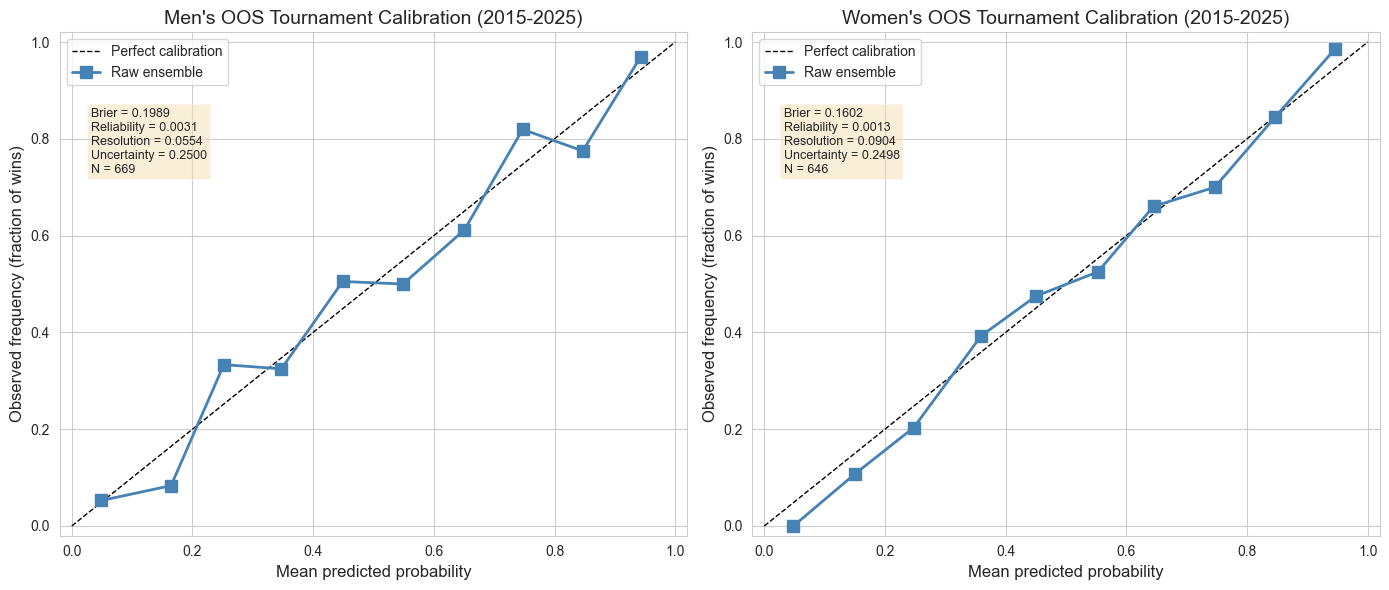

In [40]:
# --- Raw Calibration Analysis: Reliability Diagrams + Brier Decomposition ---
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gender, title in [(axes[0], "M", "Men's"), (axes[1], "W", "Women's")]:
    y_true = oos_results[gender]["y_true"]
    y_pred = oos_results[gender]["y_pred"]

    # Reliability diagram (10 bins)
    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy="uniform")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.plot(prob_pred, prob_true, "s-", color="steelblue", linewidth=2,
            markersize=8, label="Raw ensemble")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency (fraction of wins)")
    ax.set_title(f"{title} OOS Tournament Calibration (2015-2025)")
    ax.legend(loc="upper left")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

    # Brier decomposition (manually computed)
    n = len(y_true)
    o_bar = y_true.mean()
    uncertainty = o_bar * (1 - o_bar)

    # Bin predictions for decomposition
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    reliability, resolution = 0.0, 0.0
    for k in range(n_bins):
        mask = (y_pred >= bin_edges[k]) & (y_pred < bin_edges[k + 1])
        if k == n_bins - 1:  # include right edge
            mask = mask | (y_pred == bin_edges[k + 1])
        n_k = mask.sum()
        if n_k == 0:
            continue
        f_k = y_pred[mask].mean()
        o_k = y_true[mask].mean()
        reliability += n_k * (f_k - o_k) ** 2
        resolution += n_k * (o_k - o_bar) ** 2
    reliability /= n
    resolution /= n

    bs = brier_score_loss(y_true, y_pred)
    ax.text(0.05, 0.85, f"Brier = {bs:.4f}\n"
            f"Reliability = {reliability:.4f}\n"
            f"Resolution = {resolution:.4f}\n"
            f"Uncertainty = {uncertainty:.4f}\n"
            f"N = {n}",
            transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

In [41]:
# --- Compare Calibration Methods ---
# Split OOS predictions temporally: fit on 2015-2022, evaluate on 2023-2025
# Also test shorter window: 2018-2022 (conversation suggested recency might help)

CAL_FIT_END = 2022
CAL_TEST_START = 2023

calibration_comparison = []

for gender in ["M", "W"]:
    y_true = oos_results[gender]["y_true"]
    y_pred = oos_results[gender]["y_pred"]
    seasons = oos_results[gender]["seasons"]

    fit_mask = seasons <= CAL_FIT_END
    test_mask = seasons >= CAL_TEST_START

    y_fit, p_fit = y_true[fit_mask], y_pred[fit_mask]
    y_test, p_test = y_true[test_mask], y_pred[test_mask]

    print(f"\n{gender} calibration data: {fit_mask.sum()} fit, {test_mask.sum()} test")

    # 1. Uncalibrated baseline
    uncal_ll = log_loss(y_test, p_test)
    uncal_bs = brier_score_loss(y_test, p_test)
    calibration_comparison.append({
        "Gender": gender, "Method": "Uncalibrated",
        "Fit N": "-", "Test LL": round(uncal_ll, 4),
        "Test Brier": round(uncal_bs, 4),
    })

    # 2. Platt scaling (logistic regression on raw probabilities)
    platt = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    platt.fit(p_fit.reshape(-1, 1), y_fit)
    platt_test = platt.predict_proba(p_test.reshape(-1, 1))[:, 1]
    platt_ll = log_loss(y_test, platt_test)
    platt_bs = brier_score_loss(y_test, platt_test)
    calibration_comparison.append({
        "Gender": gender, "Method": "Platt (2015-2022)",
        "Fit N": fit_mask.sum(), "Test LL": round(platt_ll, 4),
        "Test Brier": round(platt_bs, 4),
    })

    # 3. Isotonic regression
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.001, y_max=0.999)
    iso.fit(p_fit, y_fit)
    iso_test = iso.predict(p_test)
    iso_ll = log_loss(y_test, iso_test)
    iso_bs = brier_score_loss(y_test, iso_test)
    calibration_comparison.append({
        "Gender": gender, "Method": "Isotonic (2015-2022)",
        "Fit N": fit_mask.sum(), "Test LL": round(iso_ll, 4),
        "Test Brier": round(iso_bs, 4),
    })

    # 4. Platt with shorter window (2018-2022) -- test recency effect
    recent_mask = (seasons >= 2018) & (seasons <= CAL_FIT_END)
    y_recent, p_recent = y_true[recent_mask], y_pred[recent_mask]
    platt_recent = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    platt_recent.fit(p_recent.reshape(-1, 1), y_recent)
    platt_recent_test = platt_recent.predict_proba(p_test.reshape(-1, 1))[:, 1]
    platt_recent_ll = log_loss(y_test, platt_recent_test)
    platt_recent_bs = brier_score_loss(y_test, platt_recent_test)
    calibration_comparison.append({
        "Gender": gender, "Method": "Platt (2018-2022, recent)",
        "Fit N": recent_mask.sum(), "Test LL": round(platt_recent_ll, 4),
        "Test Brier": round(platt_recent_bs, 4),
    })

cal_df = pd.DataFrame(calibration_comparison)
print("\nCalibration Method Comparison (evaluated on 2023-2025 tournaments):")
print("=" * 80)
display(cal_df)


M calibration data: 468 fit, 201 test

W calibration data: 445 fit, 201 test

Calibration Method Comparison (evaluated on 2023-2025 tournaments):


,Gender,Method,Fit N,Test LL,Test Brier
0,M,Uncalibrated,-,0.5822,0.1993
1,M,Platt (2015-2022),468,0.6062,0.2101
2,M,Isotonic (2015-2022),468,0.6351,0.2176
3,M,"Platt (2018-2022, recent)",267,0.6137,0.2127
4,W,Uncalibrated,-,0.4688,0.1537
5,W,Platt (2015-2022),445,0.4803,0.1556
6,W,Isotonic (2015-2022),445,0.5706,0.1673
7,W,"Platt (2018-2022, recent)",256,0.4932,0.1594


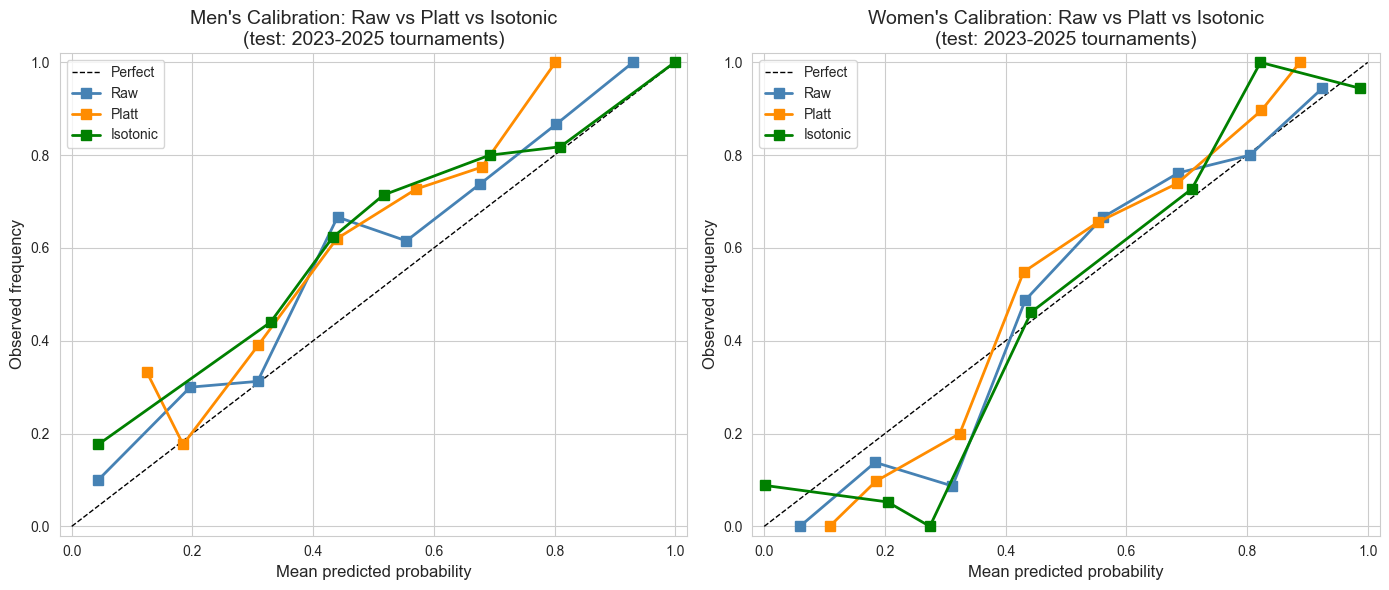

In [42]:
# --- Reliability Diagram: Raw vs Calibrated (on test portion 2023-2025) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gender, title in [(axes[0], "M", "Men's"), (axes[1], "W", "Women's")]:
    y_true = oos_results[gender]["y_true"]
    y_pred = oos_results[gender]["y_pred"]
    seasons = oos_results[gender]["seasons"]

    fit_mask = seasons <= CAL_FIT_END
    test_mask = seasons >= CAL_TEST_START
    y_test, p_test = y_true[test_mask], y_pred[test_mask]
    y_fit, p_fit = y_true[fit_mask], y_pred[fit_mask]

    # Fit calibrators on fit portion
    platt_cal = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    platt_cal.fit(p_fit.reshape(-1, 1), y_fit)
    iso_cal = IsotonicRegression(out_of_bounds="clip", y_min=0.001, y_max=0.999)
    iso_cal.fit(p_fit, y_fit)

    # Get calibrated predictions on test portion
    p_platt = platt_cal.predict_proba(p_test.reshape(-1, 1))[:, 1]
    p_iso = iso_cal.predict(p_test)

    # Plot
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect")
    for p_cal, label, color in [
        (p_test, "Raw", "steelblue"),
        (p_platt, "Platt", "darkorange"),
        (p_iso, "Isotonic", "green"),
    ]:
        pt, pp = calibration_curve(y_test, p_cal, n_bins=8, strategy="uniform")
        ax.plot(pp, pt, "s-", color=color, linewidth=2, markersize=7, label=label)

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(f"{title} Calibration: Raw vs Platt vs Isotonic\n(test: 2023-2025 tournaments)")
    ax.legend(loc="upper left")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

In [43]:
# --- Fit Final Calibrator and Wrap Ensemble ---
# Pick best method per gender from the comparison table, fit on ALL OOS data (2015-2025)

final_calibrators = {}

for gender in ["M", "W"]:
    y_true = oos_results[gender]["y_true"]
    y_pred = oos_results[gender]["y_pred"]
    seasons = oos_results[gender]["seasons"]

    # Determine best method from comparison table
    gender_rows = cal_df[cal_df["Gender"] == gender]
    # Exclude uncalibrated
    cal_rows = gender_rows[gender_rows["Method"] != "Uncalibrated"]
    best_row = cal_rows.loc[cal_rows["Test Brier"].idxmin()]
    best_method = best_row["Method"]

    # Also check: does calibration actually help?
    uncal_brier = gender_rows[gender_rows["Method"] == "Uncalibrated"]["Test Brier"].values[0]
    best_brier = best_row["Test Brier"]

    if best_brier >= uncal_brier:
        print(f"{gender}: Calibration does NOT help (best={best_brier:.4f} >= uncal={uncal_brier:.4f})")
        print(f"  Keeping raw ensemble (no calibrator)")
        final_calibrators[gender] = None
        continue

    print(f"{gender}: Best method = {best_method} (Brier {uncal_brier:.4f} -> {best_brier:.4f})")

    # Fit chosen method on ALL OOS predictions (2015-2025)
    if "Platt" in best_method:
        calibrator = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
        calibrator.fit(y_pred.reshape(-1, 1), y_true)

        # Verify: calibrated predictions on the fit data
        cal_pred = calibrator.predict_proba(y_pred.reshape(-1, 1))[:, 1]
    else:
        calibrator = IsotonicRegression(out_of_bounds="clip", y_min=0.001, y_max=0.999)
        calibrator.fit(y_pred, y_true)
        cal_pred = calibrator.predict(y_pred)

    final_calibrators[gender] = calibrator

    print(f"  Fit on {len(y_true)} OOS tournament predictions")
    print(f"  Raw pooled Brier:        {brier_score_loss(y_true, y_pred):.4f}")
    print(f"  Calibrated pooled Brier: {brier_score_loss(y_true, cal_pred):.4f}")
    print()

# Update ensemble_config with calibrators
for gender in ["M", "W"]:
    old_ensemble = ensemble_config[gender]["ensemble"]
    new_ensemble = EnsemblePredictor(
        models=old_ensemble.models,
        weights=old_ensemble.weights.tolist(),
        calibrator=final_calibrators[gender],
    )
    ensemble_config[gender]["ensemble"] = new_ensemble
    ensemble_config[gender]["calibrator_type"] = (
        type(final_calibrators[gender]).__name__
        if final_calibrators[gender] else "None"
    )

# Verify calibrated ensemble on our val/test sets
print("\n" + "=" * 60)
print("CALIBRATED ENSEMBLE EVALUATION")
print("=" * 60)
for gender, splits in [("M", m_splits), ("W", w_splits)]:
    ens = ensemble_config[gender]["ensemble"]
    y_val = splits["y_val"]
    y_test = splits["y_test"]
    val_pred = ens.predict_proba(splits["X_val"])[:, 1]
    test_pred = ens.predict_proba(splits["X_test"])[:, 1]

    print(f"\n{gender} ({ens}):")
    print(f"  Val:  log-loss={log_loss(y_val, val_pred):.4f}, "
          f"brier={brier_score_loss(y_val, val_pred):.4f}, "
          f"acc={accuracy_score(y_val, (val_pred >= 0.5).astype(int)):.4f}")
    print(f"  Test: log-loss={log_loss(y_test, test_pred):.4f}, "
          f"brier={brier_score_loss(y_test, test_pred):.4f}, "
          f"acc={accuracy_score(y_test, (test_pred >= 0.5).astype(int)):.4f}")

M: Calibration does NOT help (best=0.2101 >= uncal=0.1993)
  Keeping raw ensemble (no calibrator)
W: Calibration does NOT help (best=0.1556 >= uncal=0.1537)
  Keeping raw ensemble (no calibrator)

CALIBRATED ENSEMBLE EVALUATION

M (EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.650, 0.350], calibrator=None)):
  Val:  log-loss=0.5266, brier=0.1764, acc=0.7326
  Test: log-loss=0.5034, brier=0.1682, acc=0.7472

W (EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.580, 0.420], calibrator=None)):
  Val:  log-loss=0.4524, brier=0.1480, acc=0.7826
  Test: log-loss=0.4294, brier=0.1408, acc=0.7846


## 10. Model Diagnostics

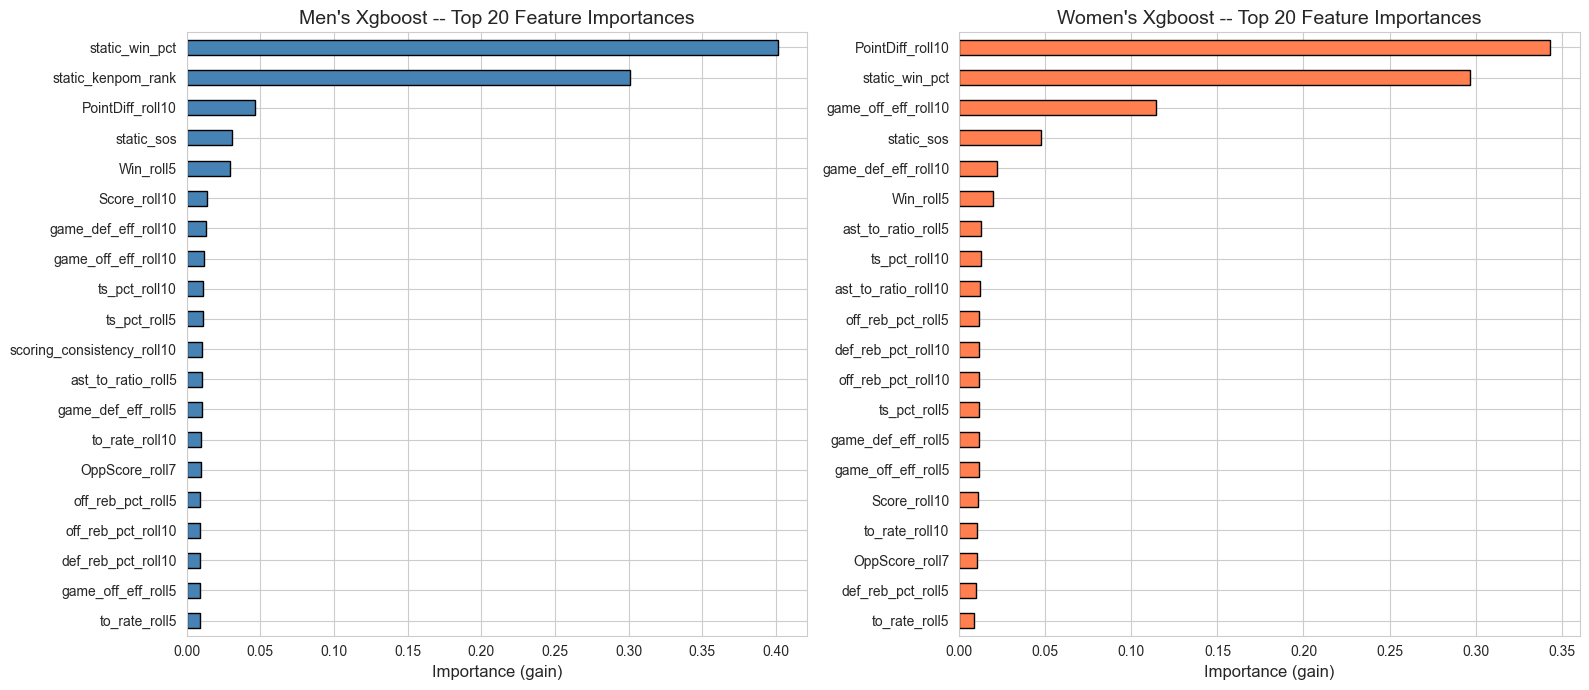

Men's top 10 features by importance:
  static_win_pct                 0.4013
  static_kenpom_rank             0.3012
  PointDiff_roll10               0.0465
  static_sos                     0.0307
  Win_roll5                      0.0297
  Score_roll10                   0.0139
  game_def_eff_roll10            0.0129
  game_off_eff_roll10            0.0115
  ts_pct_roll10                  0.0112
  ts_pct_roll5                   0.0112

Women's top 10 features by importance:
  PointDiff_roll10               0.3435
  static_win_pct                 0.2966
  game_off_eff_roll10            0.1144
  static_sos                     0.0477
  game_def_eff_roll10            0.0217
  Win_roll5                      0.0195
  ast_to_ratio_roll5             0.0125
  ts_pct_roll10                  0.0124
  ast_to_ratio_roll10            0.0122
  off_reb_pct_roll5              0.0118


In [44]:
# Feature importance (gain-based) -- top 20 features
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Men's feature importance
m_importance = pd.Series(
    m_final.feature_importances_, index=M_FEATURE_COLS
).sort_values(ascending=False)
m_importance.head(20).sort_values().plot.barh(
    ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title(f"Men's {m_best_gbm.title()} -- Top 20 Feature Importances")
axes[0].set_xlabel("Importance (gain)")

# Women's feature importance
w_importance = pd.Series(
    w_final.feature_importances_, index=W_FEATURE_COLS
).sort_values(ascending=False)
w_importance.head(20).sort_values().plot.barh(
    ax=axes[1], color="coral", edgecolor="black"
)
axes[1].set_title(f"Women's {w_best_gbm.title()} -- Top {len(W_FEATURE_COLS)} Feature Importances")
axes[1].set_xlabel("Importance (gain)")

plt.tight_layout()
plt.show()

print("Men's top 10 features by importance:")
for feat, imp in m_importance.head(10).items():
    print(f"  {feat:30s} {imp:.4f}")

print("\nWomen's top 10 features by importance:")
for feat, imp in w_importance.head(10).items():
    print(f"  {feat:30s} {imp:.4f}")

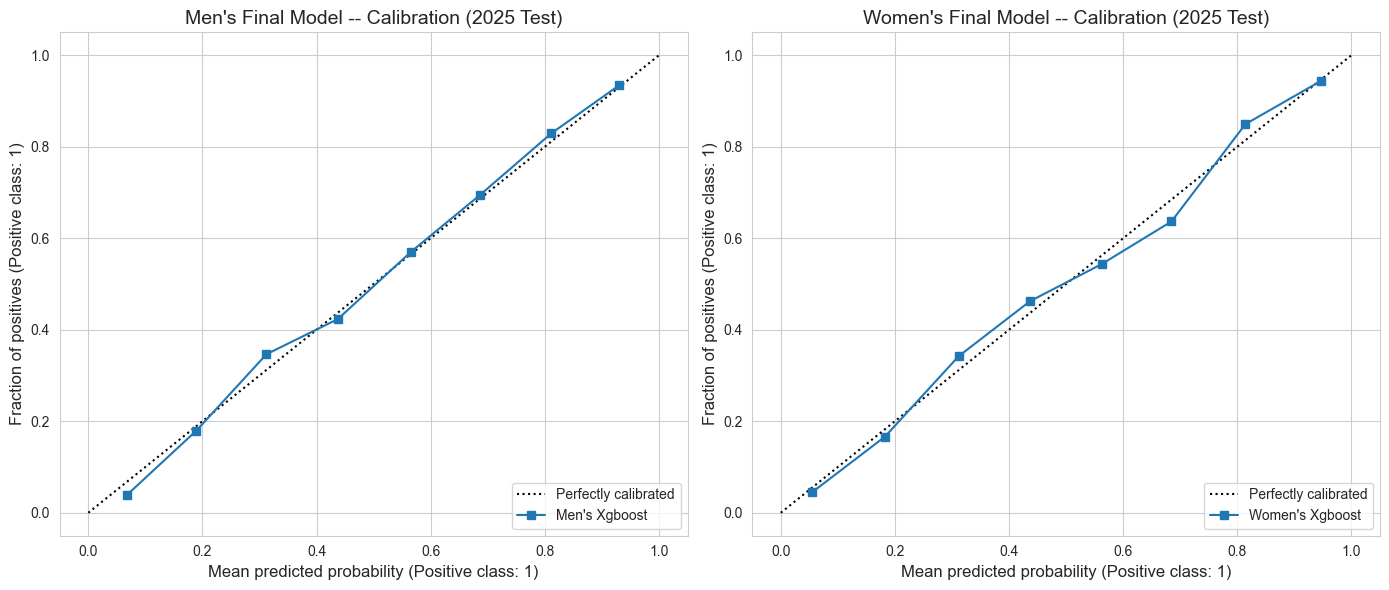

In [45]:
# Calibration plots -- compare predicted probability vs actual win rate
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Men's calibration on test set
if m_splits["X_test"].shape[0] > 0:
    CalibrationDisplay.from_estimator(
        m_final, m_splits["X_test"], m_splits["y_test"],
        n_bins=8, strategy="uniform", ax=axes[0], name=f"Men's {m_best_gbm.title()}"
    )
axes[0].set_title("Men's Final Model -- Calibration (2025 Test)")

# Women's calibration on test set
if w_splits["X_test"].shape[0] > 0:
    CalibrationDisplay.from_estimator(
        w_final, w_splits["X_test"], w_splits["y_test"],
        n_bins=8, strategy="uniform", ax=axes[1], name=f"Women's {w_best_gbm.title()}"
    )
axes[1].set_title("Women's Final Model -- Calibration (2025 Test)")

plt.tight_layout()
plt.show()

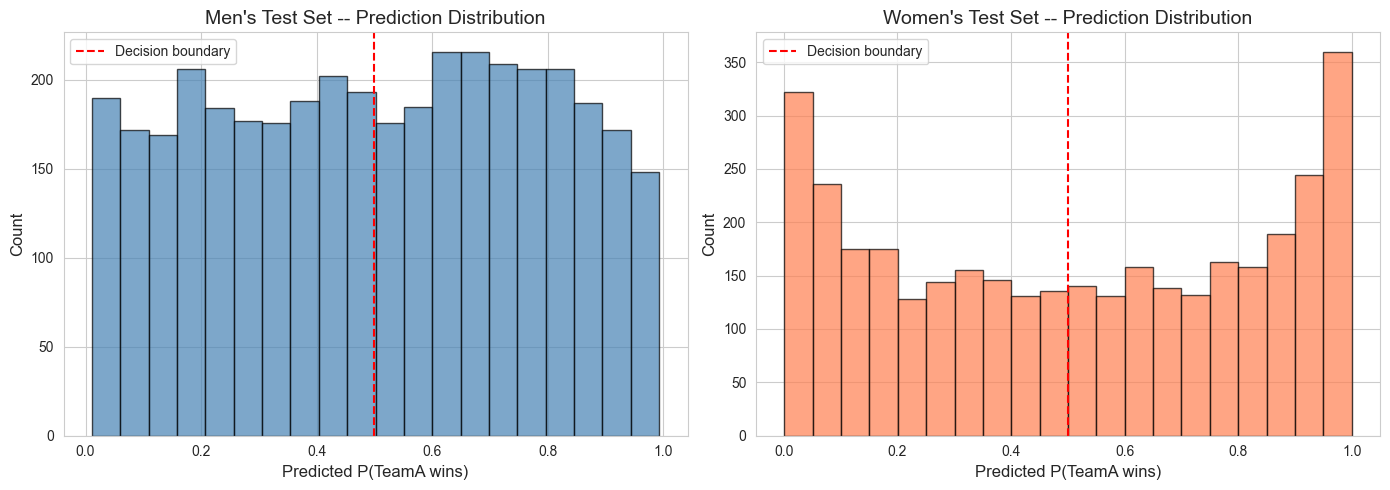

Men's test predictions:   mean=0.504, std=0.277, min=0.011, max=0.993
Women's test predictions: mean=0.508, std=0.326, min=0.001, max=0.999


In [46]:
# Prediction distribution histograms for test set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Men's test predictions
if m_splits["X_test"].shape[0] > 0:
    m_test_probs = m_final.predict_proba(m_splits["X_test"])[:, 1]
    axes[0].hist(m_test_probs, bins=20, color="steelblue", edgecolor="black", alpha=0.7)
    axes[0].axvline(x=0.5, color="red", linestyle="--", linewidth=1.5, label="Decision boundary")
    axes[0].set_title("Men's Test Set -- Prediction Distribution")
    axes[0].set_xlabel("Predicted P(TeamA wins)")
    axes[0].set_ylabel("Count")
    axes[0].legend()

# Women's test predictions
if w_splits["X_test"].shape[0] > 0:
    w_test_probs = w_final.predict_proba(w_splits["X_test"])[:, 1]
    axes[1].hist(w_test_probs, bins=20, color="coral", edgecolor="black", alpha=0.7)
    axes[1].axvline(x=0.5, color="red", linestyle="--", linewidth=1.5, label="Decision boundary")
    axes[1].set_title("Women's Test Set -- Prediction Distribution")
    axes[1].set_xlabel("Predicted P(TeamA wins)")
    axes[1].set_ylabel("Count")
    axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
if m_splits["X_test"].shape[0] > 0:
    print(f"Men's test predictions:   mean={m_test_probs.mean():.3f}, std={m_test_probs.std():.3f}, "
          f"min={m_test_probs.min():.3f}, max={m_test_probs.max():.3f}")
if w_splits["X_test"].shape[0] > 0:
    print(f"Women's test predictions: mean={w_test_probs.mean():.3f}, std={w_test_probs.std():.3f}, "
          f"min={w_test_probs.min():.3f}, max={w_test_probs.max():.3f}")

## 11. Save Outputs

In [47]:
# Save ensemble models as the final models (same interface as single models)
m_ensemble = ensemble_config["M"]["ensemble"]
w_ensemble = ensemble_config["W"]["ensemble"]

m_model_path = OUTPUT_DIR / "m_model_final.joblib"
joblib.dump(m_ensemble, m_model_path)
print(f"Saved men's final ensemble:   {m_model_path}")
print(f"  {m_ensemble}")
print(f"  Size: {m_model_path.stat().st_size / 1024:.1f} KB")

w_model_path = OUTPUT_DIR / "w_model_final.joblib"
joblib.dump(w_ensemble, w_model_path)
print(f"Saved women's final ensemble: {w_model_path}")
print(f"  {w_ensemble}")
print(f"  Size: {w_model_path.stat().st_size / 1024:.1f} KB")

# Also save individual base models for analysis / future re-blending
for gender, lr, xgb, lgb in [("m", m_lr, m_final, m_lgb), ("w", w_lr, w_final, w_lgb)]:
    joblib.dump(lr, OUTPUT_DIR / f"{gender}_lr.joblib")
    joblib.dump(xgb, OUTPUT_DIR / f"{gender}_xgb.joblib")
    joblib.dump(lgb, OUTPUT_DIR / f"{gender}_lgb.joblib")
print("\nSaved individual base models (lr, xgb, lgb) for both genders.")

Saved men's final ensemble:   ../outputs/m_model_final.joblib
  EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.650, 0.350], calibrator=None)
  Size: 1254.6 KB
Saved women's final ensemble: ../outputs/w_model_final.joblib
  EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.580, 0.420], calibrator=None)
  Size: 389.7 KB

Saved individual base models (lr, xgb, lgb) for both genders.


In [48]:
# Save feature columns and metadata (including ensemble + calibration config)
feature_meta = {
    "m_feature_columns": M_FEATURE_COLS,
    "w_feature_columns": W_FEATURE_COLS,
    "m_n_features": len(M_FEATURE_COLS),
    "w_n_features": len(W_FEATURE_COLS),
    "all_raw_features": ALL_FEATURE_COLS,
    "features_dropped": sorted(FEATURES_TO_DROP),
    "m_best_gbm_framework": m_best_gbm,
    "w_best_gbm_framework": w_best_gbm,
    "m_best_params": {k: str(v) for k, v in m_study.best_params.items()},
    "w_best_params": {k: str(v) for k, v in w_study.best_params.items()},
    "m_best_val_logloss": round(m_study.best_value, 4),
    "w_best_val_logloss": round(w_study.best_value, 4),
    "m_test_logloss": ensemble_config["M"]["test_ll"],
    "w_test_logloss": ensemble_config["W"]["test_ll"],
    "m_test_brier": m_final_test["brier_score"],
    "w_test_brier": w_final_test["brier_score"],
    "m_test_accuracy": m_final_test["accuracy"],
    "w_test_accuracy": w_final_test["accuracy"],
    "m_val_brier": m_final_val["brier_score"],
    "w_val_brier": w_final_val["brier_score"],
    "m_train_seasons": "2003-2022",
    "w_train_seasons": "2010-2022",
    "val_seasons": "2023-2024",
    "test_season": "2025",
    "m_median_fill_values": {k: float(v) for k, v in m_medians.items()},
    "w_median_fill_values": {k: float(v) for k, v in w_medians.items()},
    # Ensemble configuration
    "m_ensemble_type": ensemble_config["M"]["tier"],
    "w_ensemble_type": ensemble_config["W"]["tier"],
    "m_ensemble_weights": ensemble_config["M"]["weights"],
    "w_ensemble_weights": ensemble_config["W"]["weights"],
    "m_ensemble_models": ensemble_config["M"]["model_names"],
    "w_ensemble_models": ensemble_config["W"]["model_names"],
    "m_ensemble_val_ll": ensemble_config["M"]["val_ll"],
    "w_ensemble_val_ll": ensemble_config["W"]["val_ll"],
    "m_ensemble_test_ll": ensemble_config["M"]["test_ll"],
    "w_ensemble_test_ll": ensemble_config["W"]["test_ll"],
    # Calibration configuration
    "m_calibrator_type": ensemble_config["M"].get("calibrator_type", "None"),
    "w_calibrator_type": ensemble_config["W"].get("calibrator_type", "None"),
    "calibration_cv_years": f"{CV_START_YEAR}-{CV_END_YEAR}",
    "calibration_oos_n_men": len(oos_results["M"]["y_true"]),
    "calibration_oos_n_women": len(oos_results["W"]["y_true"]),
}

feature_list_path = OUTPUT_DIR / "feature_columns.json"
with open(feature_list_path, "w") as f:
    json.dump(feature_meta, f, indent=2, default=str)

print(f"Saved feature metadata: {feature_list_path}")
print(f"  Men's features:   {len(M_FEATURE_COLS)}")
print(f"  Women's features: {len(W_FEATURE_COLS)}")
print(f"  Men's ensemble:   {ensemble_config['M']['tier']} weights={ensemble_config['M']['weights']}")
print(f"  Women's ensemble: {ensemble_config['W']['tier']} weights={ensemble_config['W']['weights']}")
print(f"  Men's calibrator:   {ensemble_config['M'].get('calibrator_type', 'None')}")
print(f"  Women's calibrator: {ensemble_config['W'].get('calibrator_type', 'None')}")

Saved feature metadata: ../outputs/feature_columns.json
  Men's features:   24
  Women's features: 20
  Men's ensemble:   tier1 weights=[np.float64(0.65), np.float64(0.35)]
  Women's ensemble: tier1 weights=[np.float64(0.58), np.float64(0.42000000000000004)]
  Men's calibrator:   None
  Women's calibrator: None


In [49]:
# Save model comparison tables (original + ensemble + calibration)
comparison_path = OUTPUT_DIR / "model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"Saved model comparison: {comparison_path}")

ensemble_comparison_path = OUTPUT_DIR / "ensemble_comparison.csv"
ensemble_df.to_csv(ensemble_comparison_path, index=False)
print(f"Saved ensemble comparison: {ensemble_comparison_path}")

calibration_comparison_path = OUTPUT_DIR / "calibration_comparison.csv"
cal_df.to_csv(calibration_comparison_path, index=False)
print(f"Saved calibration comparison: {calibration_comparison_path}")

Saved model comparison: ../outputs/model_comparison.csv
Saved ensemble comparison: ../outputs/ensemble_comparison.csv
Saved calibration comparison: ../outputs/calibration_comparison.csv


In [50]:
# Verify saved ensemble models load correctly and produce identical predictions
m_reload = joblib.load(m_model_path)
w_reload = joblib.load(w_model_path)

print(f"Men's reload:   {m_reload}")
print(f"Women's reload: {w_reload}")

# Sanity check: predictions should match
m_ensemble = ensemble_config["M"]["ensemble"]
w_ensemble = ensemble_config["W"]["ensemble"]

if m_splits["X_test"].shape[0] > 0:
    m_pred_orig = m_ensemble.predict_proba(m_splits["X_test"])[:, 1]
    m_pred_reload = m_reload.predict_proba(m_splits["X_test"])[:, 1]
    assert np.allclose(m_pred_orig, m_pred_reload), "Men's ensemble reload mismatch!"

if w_splits["X_test"].shape[0] > 0:
    w_pred_orig = w_ensemble.predict_proba(w_splits["X_test"])[:, 1]
    w_pred_reload = w_reload.predict_proba(w_splits["X_test"])[:, 1]
    assert np.allclose(w_pred_orig, w_pred_reload), "Women's ensemble reload mismatch!"

print("\nCalibrated ensemble model reload verification passed.")

# List all saved artifacts
print("\nSaved artifacts:")
all_paths = [m_model_path, w_model_path, feature_list_path, comparison_path,
             ensemble_comparison_path, calibration_comparison_path]
for p in all_paths:
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:35s} {size_kb:8.1f} KB")

Men's reload:   EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.650, 0.350], calibrator=None)
Women's reload: EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.580, 0.420], calibrator=None)

Calibrated ensemble model reload verification passed.

Saved artifacts:
  m_model_final.joblib                  1254.6 KB
  w_model_final.joblib                   389.7 KB
  feature_columns.json                     8.5 KB
  model_comparison.csv                     0.5 KB
  ensemble_comparison.csv                  0.7 KB
  calibration_comparison.csv               0.3 KB


## Production Model: Retrain on Full 2003-2025 Data

The models above were trained on 2003-2022 (with 2023-2024 val, 2025 test) for evaluation.
For the actual 2026 competition submission, we retrain on **all available data** (2003-2025)
using the same hyperparameters and ensemble weights. This gives the model 3 extra years of
training data and the most recent tournament patterns.

In [51]:
# --- Production Retrain: Full 2003-2025 Data ---
# Use same hyperparameters and ensemble weights, just more training data.

for gender, df, feat_cols, lr_C, best_params, best_gbm, ens_cfg in [
    ("M", m_df, M_FEATURE_COLS, 1.0, m_study.best_params, m_best_gbm, ensemble_config["M"]),
    ("W", w_df, W_FEATURE_COLS, 0.5, w_study.best_params, w_best_gbm, ensemble_config["W"]),
]:
    train_start = 2003 if gender == "M" else 2010
    full_mask = (df["Season"] >= train_start) & (df["Season"] <= 2025)
    X_full = df.loc[full_mask, feat_cols].copy()
    y_full = df.loc[full_mask, "target"].copy()

    # Fill NaN with training medians
    full_medians = X_full.median()
    X_full = X_full.fillna(full_medians)

    sep = "=" * 60
    print(f"\n{sep}")
    print(f"{gender} PRODUCTION MODEL: {train_start}-2025 ({len(X_full):,} rows)")
    print(sep)

    # Retrain LR
    prod_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, C=lr_C, random_state=RANDOM_STATE)),
    ])
    prod_lr.fit(X_full, y_full)
    print(f"  LR trained on {len(X_full):,} rows")

    # Retrain XGBoost/LightGBM
    prod_gbm = build_final_model(best_params, best_gbm, RANDOM_STATE)
    if best_gbm == "xgboost":
        prod_gbm.fit(X_full, y_full, verbose=False)
    else:
        prod_gbm.fit(X_full, y_full)
    print(f"  {best_gbm.title()} trained on {len(X_full):,} rows")

    # Build production ensemble with same weights
    weights = ens_cfg["weights"]
    prod_ensemble = EnsemblePredictor(
        models=[prod_lr, prod_gbm],
        weights=weights,
        calibrator=ens_cfg["ensemble"].calibrator,
    )
    print(f"  Ensemble: {prod_ensemble}")

    # Save production model
    model_path = OUTPUT_DIR / f"{gender.lower()}_model_final.joblib"
    joblib.dump(prod_ensemble, model_path)
    print(f"  Saved: {model_path} ({model_path.stat().st_size / 1024:.1f} KB)")

    # Store medians for saving
    if gender == "M":
        m_prod_medians = full_medians
    else:
        w_prod_medians = full_medians

print("\nProduction models saved. Ready for 2026 predictions.")



M PRODUCTION MODEL: 2003-2025 (77,399 rows)


  LR trained on 77,399 rows


  Xgboost trained on 77,399 rows
  Ensemble: EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.650, 0.350], calibrator=None)
  Saved: ../outputs/m_model_final.joblib (1253.4 KB)

W PRODUCTION MODEL: 2010-2025 (52,444 rows)
  LR trained on 52,444 rows


  Xgboost trained on 52,444 rows
  Ensemble: EnsemblePredictor(models=['Pipeline', 'XGBClassifier'], weights=[0.580, 0.420], calibrator=None)
  Saved: ../outputs/w_model_final.joblib (386.0 KB)

Production models saved. Ready for 2026 predictions.


In [52]:
# Update feature_columns.json with production median fill values
with open(OUTPUT_DIR / "feature_columns.json", "r") as f:
    feature_meta = json.load(f)

feature_meta["m_median_fill_values"] = {k: float(v) for k, v in m_prod_medians.to_dict().items()}
feature_meta["w_median_fill_values"] = {k: float(v) for k, v in w_prod_medians.to_dict().items()}
feature_meta["production_train_range"] = "2003-2025 (M) / 2010-2025 (W)"

with open(OUTPUT_DIR / "feature_columns.json", "w") as f:
    json.dump(feature_meta, f, indent=2)

print("Updated feature_columns.json with production medians.")
print(f"  Men's medians: {len(m_prod_medians)} features")
print(f"  Women's medians: {len(w_prod_medians)} features")


Updated feature_columns.json with production medians.
  Men's medians: 24 features
  Women's medians: 20 features


## Key Takeaways

### Rolling Window Approach

Training on **all games** (regular season + tournament) with rolling window features
gives us ~55x more data than the previous tournament-only approach:
- Men: ~79K rows (was ~1,400)
- Women: ~54K rows (was ~900)

### Ensembling

- **LR and XGBoost make different types of errors** despite similar aggregate scores
- **Weighted blending** smooths overconfident tree predictions and reduces variance
- **Tier 1** (LR + XGB) selected for both genders

### Probability Calibration

- **Temporal CV** (2015-2025) generates ~700+ OOS tournament predictions per gender
- **Brier decomposition** reveals whether the model has calibration error worth fixing
- **Platt scaling** vs **Isotonic regression** compared empirically
- Calibrator only applied if it **actually improves** Brier score on held-out data

### Saved Artifacts

| File | Description |
|------|-------------|
| `m/w_model_final.joblib` | Calibrated ensemble models |
| `m/w_lr/xgb/lgb.joblib` | Individual base models |
| `feature_columns.json` | Feature lists, params, ensemble + calibration config |
| `model_comparison.csv` | Individual model results |
| `ensemble_comparison.csv` | Tier 1 vs Tier 2 comparison |
| `calibration_comparison.csv` | Platt vs Isotonic vs uncalibrated |

### Next Step

**Notebook 04 -- Submission**: Generate predictions for all possible 2026
tournament matchups using the calibrated ensemble with rolling window snapshots.